# 02.2 · Hierarchical Naive Bayes follow-up

This notebook preserves the hierarchical signed-evidence analysis from Notebook 02 and adds a **raw-variable, non-glycemic XGBoost audit** for recovering the fixed C0–C9 community labels.

The final XGBoost classifier does **not** use the interval bins created for signed Bayes evidence. Numerical predictors enter in their prepared original-value form, categorical predictors remain source-variable representations handled by the project preprocessing, and missing/non-response text categories are converted to missing values rather than modeled as categories.


## 1. Initialization and handoff loading

In [1]:
from pathlib import Path
import importlib
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

_current = Path.cwd().expanduser().resolve()
PROJECT_ROOT = next(
    (
        candidate for candidate in [_current, *_current.parents]
        if (candidate / "src" / "ensanut_hba1c").is_dir()
        and (candidate / "data" / "input").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("The project root could not be located.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Remove stale package versions retained by an existing notebook kernel.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

from ensanut_hba1c.paths import ProjectPaths
from ensanut_hba1c.io import load_notebook_handoff

PATHS = ProjectPaths(PROJECT_ROOT).ensure()
HANDOFF_DIR = PATHS.handoff_dir
OUTPUT_DIR = PATHS.notebook2_results

# Normally these paths should remain None. Use them only when the cluster
# dataset or dictionary is stored outside the current project.
EXTERNAL_CLUSTER_DATASET_PATH = None
EXTERNAL_DICTIONARY_PATH = None

AUTO_DISCOVER_PREVIOUS_HANDOFF = True
HANDOFF_SEARCH_ROOTS = [PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent]
HANDOFF_SEARCH_MAX_DEPTH = 5
PERSIST_RECOVERED_HANDOFF = True

fallback_cluster_paths = [
    PATHS.notebook1_results / "complete_cluster_dataset.pkl",
    PATHS.notebook1_results / "complete_cluster_dataset.csv",
]
fallback_dictionary_paths = [PATHS.input_dir / "ENSANUT_2024.csv"]
if EXTERNAL_CLUSTER_DATASET_PATH is not None:
    fallback_cluster_paths.insert(0, Path(EXTERNAL_CLUSTER_DATASET_PATH).expanduser())
if EXTERNAL_DICTIONARY_PATH is not None:
    fallback_dictionary_paths.insert(0, Path(EXTERNAL_DICTIONARY_PATH).expanduser())

cluster_df, data_dictionary_df, handoff_metadata, handoff_sources = load_notebook_handoff(
    HANDOFF_DIR,
    fallback_cluster_paths=fallback_cluster_paths,
    fallback_dictionary_paths=fallback_dictionary_paths,
    auto_discover_search_roots=(HANDOFF_SEARCH_ROOTS if AUTO_DISCOVER_PREVIOUS_HANDOFF else []),
    auto_discover_max_depth=HANDOFF_SEARCH_MAX_DEPTH,
    persist_recovered_handoff=PERSIST_RECOVERED_HANDOFF,
    cluster_column="Cluster_SHAP",
)

CLUSTER_COLUMN = "Cluster_SHAP"

RUN_CONTEXT = pd.DataFrame([{
    "cluster_rows": len(cluster_df),
    "dictionary_rows": len(data_dictionary_df),
    "n_clusters": cluster_df[CLUSTER_COLUMN].nunique(dropna=True),
    "cluster_source": str(handoff_sources["cluster"]),
    "dictionary_source": str(handoff_sources["dictionary"]),
}])
display(RUN_CONTEXT)





,cluster_rows,dictionary_rows,n_clusters,cluster_source,dictionary_source
0,2530,2695,10,/Users/cristianjuliocesarpadronmanrique/Deskto...,/Users/cristianjuliocesarpadronmanrique/Deskto...


## 2. Editable Naive Bayes evidence parameters

In [2]:
RUN_SIGNED_EVIDENCE_ANALYSIS = True
RUN_PRIMARY_LEVEL = True
RUN_SECONDARY_LEVEL = True

BAYES_N_BINS = 10
BAYES_ALPHA = 1.0
BAYES_MIN_CASES = 20
BAYES_EPSILON_THRESHOLD = 1.96
BAYES_FORCE_EXACT_FEATURE_BINS = False
MAX_INFERRED_CATEGORIES = 50
MINIMUM_VARIABLES_PER_GROUP = 2
TOP_RULES_PER_CLUSTER = 10

# Publication-workbook thresholds.
EXPORT_MIN_NX = 40
EXPORT_MIN_N_CLUSTER_X = 40
EXPORT_MIN_SCORE = 0.5

SELECTED_PRIMARY_GROUPS = None
SELECTED_SECONDARY_GROUPS = None

SHOW_PROGRESS_BAR = True
PROGRESS_LEAVE = True
PROGRESS_MININTERVAL = 0.25
SAVE_GROUP_FIGURES = False
SAVE_TOP_RULE_TABLES = True

## 3. Editable PyComplexHeatmap parameters

In [3]:
RUN_COMPLEX_HEATMAPS = True
PUBLICATION_DPI = 600
HEATMAP_LANGUAGE = "en"
HEATMAP_FONT_FAMILY = "DejaVu Sans"

POSITIVE_CMAP = "Reds"
NEGATIVE_CMAP = "Blues"
NET_CMAP = "RdBu_r"
ROBUST_COLOR_PERCENTILE = 95.0
GENERATE_NET_HEATMAP = True
SHOW_CELL_VALUES = False
HEATMAP_RASTERIZED = False

PANEL_WIDTH_INCHES = 1.0
ROW_HEIGHT_INCHES = 0.10
MINIMUM_FIGURE_HEIGHT = 4.0
MAXIMUM_FIGURE_HEIGHT = 26.0
COLUMN_GAP_MM = 8.0
ROW_SPLIT_GAP_MM = 1.2

ROW_LABEL_FONTSIZE = 7.5
COLUMN_LABEL_FONTSIZE = 8.0
TITLE_FONTSIZE = 13.0
PANEL_TITLE_FONTSIZE = 10.5
CLUSTER_ANNOTATION_FONTSIZE = 7.0
SHOW_FIGURE_TITLE = False
SHOW_PANEL_TITLES = False

SHOW_CLUSTER_SIZE_ANNOTATION = True
SHOW_CLUSTER_STRIP_ANNOTATION = True
SHOW_BOTTOM_CLUSTER_NUMBERS = True
SHOW_PRIMARY_ROW_ANNOTATION = True
PRIMARY_ROW_ANNOTATION_CMAP = "tab20"
PRIMARY_ROW_ANNOTATION_WIDTH_MM = 5.0
PRIMARY_ROW_ANNOTATION_LEGEND = True
PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS = 4

CLUSTER_ROWS = True
CLUSTER_COLUMNS = True
CLUSTERING_BASIS = "combined"       # combined | positive | negative | net
CLUSTERING_METRIC = "correlation"
CLUSTERING_METHOD = "average"
CLUSTER_SECONDARY_WITHIN_PRIMARY = True
ROW_DENDROGRAM = False
COLUMN_DENDROGRAM = False


## 4. Editable exclusions applied before any calculation

Two visible exclusion lists are used:

1. `NB_FRAMEWORK_EXCLUDE_VARIABLES`: permanent scientific exclusions from the NB framework.
2. `NOTEBOOK2_EXCLUDE_VARIABLES`: additional or temporary exclusions for Notebook 2.1.

Both lists are applied before binning, NB score calculation, epsilon calculation,
heatmap generation, and table export.


In [4]:
ID_COLUMNS = ["FOLIO_I", "FOLIO_INT"]
TARGET_COLUMN = []  # The cluster is defined by CLUSTER_COLUMN; HbA1c is not a predictor.

# -----------------------------------------------------------------------------
# MANDATORY SCIENTIFIC EXCLUSIONS
# These columns cannot enter binning, NB scoring, coverage, heatmaps, or
# the final XGBoost model. Separate lists keep the audit explicit and
# provide a second safety barrier at the final stage.
# -----------------------------------------------------------------------------
REDUNDANT_AGE_COLUMNS = [
    "gpoedad", "annac", "mesnac", "fecha_nacimiento", "H0304A", "H0304M",
    "FECH_NAC", "edad", "AEDAD", "A0302", "MESES",
]

TARGET_DERIVED_COLUMNS = [
    "hba1c_class_cat", "hba1c_class_bin", "clasif_hba1c_cat", "clasif_hba1c_bin",
    "preferred_combined_class_bin", "preferred_combined_class_cat",
    "clasif_combinada_pref_bin", "clasif_combinada_pref_cat",
    "HbA1c_Status", "Estado_HbA1c",
]

# Serum glucose and direct glucose-derived encodings are excluded from BOTH
# the signed-evidence framework and the downstream binary XGBoost audit.
GLUCOSE_DIRECT_OR_DERIVED_COLUMNS = [
    "GLU_SUERO",
    "glucose_class_cat", "glucose_class_bin",
    "clasif_glucosa_cat", "clasif_glucosa_bin",
    "Glucose_Status", "Estado_Glucosa",
    "Metabolic_Syndrome_Status",  # includes a glucose criterion
]

# Additional direct-outcome or leakage variables excluded from the framework.
DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS = sorted(set([
    "HB1AC",
    *GLUCOSE_DIRECT_OR_DERIVED_COLUMNS,
]))

# -----------------------------------------------------------------------------
# LIST 1: variables excluded from the Naive Bayes framework.
# Excluded before binning, counts, score, epsilon, coverage, heatmaps,
# and Excel exports.
# -----------------------------------------------------------------------------
NB_FRAMEWORK_EXCLUDE_VARIABLES = sorted(set(
    DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
    + TARGET_DERIVED_COLUMNS
    + REDUNDANT_AGE_COLUMNS
))

# -----------------------------------------------------------------------------
# LIST 2: additional variables not processed in Notebook 2.
# Leave empty or add codes exactly as they appear in cluster_df.
# Example: "VAR001", "VAR002"
# -----------------------------------------------------------------------------
NOTEBOOK2_EXCLUDE_VARIABLES = [
    # "VAR001",
]

# Automatic exclusions for identifiers, technical representations, and macroclusters.
AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS = [
    *ID_COLUMNS,
    "Cluster_SHAP_macro",
    *[
        column for column in cluster_df.columns
        if column.startswith("PCA_")
        or column.startswith("UMAP_VISUAL_")
        or column.startswith("UMAP_GRAPH_PHATE_")
        or column.startswith("Mellon_")
    ],
]

BAYES_EXCLUDE_COLUMNS = sorted(set(
    NB_FRAMEWORK_EXCLUDE_VARIABLES
    + NOTEBOOK2_EXCLUDE_VARIABLES
    + AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS
))

eligible_variables = sorted(
    set(cluster_df.columns)
    .difference(BAYES_EXCLUDE_COLUMNS)
    .difference({CLUSTER_COLUMN})
)

# Explicit audit of each exclusion source and its presence in the dataset.
exclusion_source = {}
for variable in DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Direct outcome/leakage")
for variable in TARGET_DERIVED_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Target-derived")
for variable in REDUNDANT_AGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Redundant/derived age")
for variable in NOTEBOOK2_EXCLUDE_VARIABLES:
    exclusion_source.setdefault(str(variable), []).append("Notebook 2")
for variable in AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Automatic/technical")

exclusion_audit = pd.DataFrame([
    {
        "var": variable,
        "exclusion_source": " + ".join(sources),
        "present_in_cluster_df": variable in cluster_df.columns,
        "processed_by_nb": False,
    }
    for variable, sources in sorted(exclusion_source.items())
])
exclusion_audit.to_csv(
    OUTPUT_DIR / "notebook2_variable_exclusions.csv",
    index=False,
)

print("Total variables in cluster_df:", cluster_df.shape[1])
print("Excluded variables:", len(BAYES_EXCLUDE_COLUMNS))
print("NB-eligible variables:", len(eligible_variables))
print("Serum glucose excluded:", "GLU_SUERO" in BAYES_EXCLUDE_COLUMNS)
display(exclusion_audit)


Total variables in cluster_df: 2765
Excluded variables: 87
NB-eligible variables: 2696
Serum glucose excluded: True


,var,exclusion_source,present_in_cluster_df,processed_by_nb
0,A0302,Redundant/derived age,True,False
1,AEDAD,Redundant/derived age,True,False
2,Cluster_SHAP_macro,Automatic/technical,True,False
3,Estado_Glucosa,Direct outcome/leakage,False,False
4,Estado_HbA1c,Target-derived,False,False
...,...,...,...,...
82,hba1c_class_bin,Target-derived,False,False
83,hba1c_class_cat,Target-derived,False,False
84,mesnac,Redundant/derived age,False,False
85,preferred_combined_class_bin,Target-derived,False,False


## 5. Data-dictionary hierarchy

In [5]:
from ensanut_hba1c.bayes.hierarchy import hierarchy_tree_text, parse_dictionary_hierarchy

(
    dictionary_hierarchy_df,
    dictionary_hierarchy_summary,
    PRIMARY_VARIABLE_GROUPS,
    SECONDARY_VARIABLE_GROUPS,
) = parse_dictionary_hierarchy(data_dictionary_df)

eligible_set = set(eligible_variables)
PRIMARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in PRIMARY_VARIABLE_GROUPS.items()
}
SECONDARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in SECONDARY_VARIABLE_GROUPS.items()
}
print(hierarchy_tree_text(dictionary_hierarchy_summary))
display(dictionary_hierarchy_summary)


/opt/anaconda3/envs/ensanut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


■ ACTIVIDAD FISICA
  ├── MODULO ACTIVIDAD FISICA ADULTOS (30 variables; 30 rows)
  └── MODULO ACTIVIDAD FISICA NIÑOS (38 variables; 38 rows)

■ AGREGACIÓN POR GRUPOS NUTRICIONALES
  └── (sin subnivel) (29 variables; 29 rows)

■ ANTROPOMETRÍA Y PRESIÓN ARTERIAL
  └── (sin subnivel) (11 variables; 11 rows)

■ ENF
  └── CRÓNICAS (10 variables; 10 rows)

■ ETIQUETADO FRONTAL
  └── (sin subnivel) (87 variables; 87 rows)

■ FRECUENCIA DE ALIMENTOS
  └── (sin subnivel) (277 variables; 277 rows)

■ HEMOGLOBINA
  └── (sin subnivel) (2 variables; 2 rows)

■ HOGAR
  ├── I CARACTERÍSTICAS DE LA VIVIENDA (24 variables; 24 rows)
  ├── II IDENTIFICACIÓN DE HOGARES (4 variables; 4 rows)
  ├── III CARACTERÍSTICAS SOCIODEMOGRÁFICAS (1 variables; 1 rows)
  ├── IV SITUACIÓN DE SALUD Y UTILIZACIÓN DE SERVICIOS DE SALUD (3 variables; 3 rows)
  ├── MODULO HOGAR (11 variables; 11 rows)
  ├── V OTRAS CARACTERÍSTICAS DEL HOGAR (20 variables; 20 rows)
  ├── VII SEGURIDAD ALIMENTARIA (16 variables; 16 rows)
  └──

,nivel_primario,nivel_secundario,ruta_jerarquica,n_filas,n_variables_unicas
0,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA ADULTOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,30,30
1,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA NIÑOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA NIÑOS,38,38
2,AGREGACIÓN POR GRUPOS NUTRICIONALES,(sin subnivel),AGREGACIÓN POR GRUPOS NUTRICIONALES,29,29
3,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,(sin subnivel),ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11
4,ENF,CRÓNICAS,ENF > CRÓNICAS,10,10
...,...,...,...,...,...
64,SERVICIOS SALUD,(sin subnivel),SERVICIOS SALUD,12,12
65,SERVICIOS SALUD,I UTILIZACIÓN,SERVICIOS SALUD > I UTILIZACIÓN,2,2
66,SERVICIOS SALUD,II ATENCIÓN,SERVICIOS SALUD > II ATENCIÓN,36,36
67,SERVICIOS SALUD,III MEDICAMENTOS,SERVICIOS SALUD > III MEDICAMENTOS,9,9


## 6. Calculate positive and negative evidence

In [6]:
import importlib
import inspect

# Mandatory reload: avoids stale kernels that retained an earlier
# SignedEvidenceConfig without the export-threshold parameters.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

import ensanut_hba1c.bayes.hierarchy as bayes_hierarchy
bayes_hierarchy = importlib.reload(bayes_hierarchy)

module_path = Path(bayes_hierarchy.__file__).resolve()
expected_module_path = (SRC_DIR / "ensanut_hba1c" / "bayes" / "hierarchy.py").resolve()
if module_path != expected_module_path:
    raise RuntimeError(
        "ensanut_hba1c was imported from a different project path. "
        f"Imported path: {module_path}. Expected path: {expected_module_path}. "
        "Restart the kernel and run Notebook 2 from the first cell."
    )

SignedEvidenceConfig = bayes_hierarchy.SignedEvidenceConfig
run_hierarchical_signed_evidence_analysis = bayes_hierarchy.run_hierarchical_signed_evidence_analysis

required_export_parameters = {"export_min_nx", "export_min_n_cluster_x", "export_min_score"}
available_config_parameters = set(inspect.signature(SignedEvidenceConfig).parameters)
missing_export_parameters = required_export_parameters.difference(available_config_parameters)
if missing_export_parameters:
    raise RuntimeError(
        "SignedEvidenceConfig is outdated and does not contain: "
        f"{sorted(missing_export_parameters)}. Loaded module: {module_path}"
    )

print("Loaded NB module:", module_path)
print("Verified export parameters:", sorted(required_export_parameters))

SUMMARY_PATH = OUTPUT_DIR / "signed_evidence_all_groups.csv"
COVERAGE_PATH = OUTPUT_DIR / "group_coverage.csv"

if RUN_SIGNED_EVIDENCE_ANALYSIS:
    SIGNED_CONFIG = SignedEvidenceConfig(
        n_bins_features=BAYES_N_BINS,
        alpha=BAYES_ALPHA,
        min_cases=BAYES_MIN_CASES,
        epsilon_threshold=BAYES_EPSILON_THRESHOLD,
        force_exact_feature_bins=BAYES_FORCE_EXACT_FEATURE_BINS,
        max_inferred_categories=MAX_INFERRED_CATEGORIES,
        minimum_variables_per_group=MINIMUM_VARIABLES_PER_GROUP,
        top_rules_per_cluster=TOP_RULES_PER_CLUSTER,
        publication_dpi=PUBLICATION_DPI,
        show_progress_bar=SHOW_PROGRESS_BAR,
        progress_leave=PROGRESS_LEAVE,
        progress_mininterval=PROGRESS_MININTERVAL,
        save_group_figures=SAVE_GROUP_FIGURES,
        save_top_rule_tables=SAVE_TOP_RULE_TABLES,
        save_complex_heatmaps=False,
        complex_heatmap_robust_percentile=ROBUST_COLOR_PERCENTILE,
        export_min_nx=EXPORT_MIN_NX,
        export_min_n_cluster_x=EXPORT_MIN_N_CLUSTER_X,
        export_min_score=EXPORT_MIN_SCORE,
    )
    signed_results = run_hierarchical_signed_evidence_analysis(
        cluster_df=cluster_df,
        dictionary_df=data_dictionary_df,
        output_dir=OUTPUT_DIR,
        cluster_column=CLUSTER_COLUMN,
        excluded_columns=BAYES_EXCLUDE_COLUMNS,
        run_primary_level=RUN_PRIMARY_LEVEL,
        run_secondary_level=RUN_SECONDARY_LEVEL,
        config=SIGNED_CONFIG,
        selected_primary_groups=SELECTED_PRIMARY_GROUPS,
        selected_secondary_groups=SELECTED_SECONDARY_GROUPS,
    )
    weighted_summary = signed_results["summary"].copy()
    group_coverage = signed_results["coverage"].copy()
    filtered_rules = signed_results["filtered_rules_table"].copy()
    print("Main workbook with coverage:", signed_results["workbook_path"])
    print("Workbook containing all variables:", signed_results["all_variables_workbook_path"])
    print("Single workbook containing all row-level operations:", signed_results["internal_operations_workbook_path"])
    print("Filtered rules in the main workbook:", len(filtered_rules))
else:
    weighted_summary = pd.read_csv(SUMMARY_PATH)
    group_coverage = pd.read_csv(COVERAGE_PATH) if COVERAGE_PATH.is_file() else pd.DataFrame()

display(group_coverage)
display(weighted_summary.head(150))

Loaded NB module: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/src/ensanut_hba1c/bayes/hierarchy.py
Verified export parameters: ['export_min_n_cluster_x', 'export_min_nx', 'export_min_score']


Primary/secondary Bayes evidence: 100%|█| 85/85 [00:12<00:00,  6.69group/s, sec


Main workbook with coverage: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence.xlsx
Workbook containing all variables: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence_all_variables.xlsx
Single workbook containing all row-level operations: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/bayes_internal_operations_all_variables.xlsx
Filtered rules in the main workbook: 1367


,level,group,n_requested_variables,n_usable_variables,n_encoded_variables,n_binary_rules,n_clusters,status,reason
0,primary,ACTIVIDAD FISICA,68,68,30.0,222.0,10.0,completed,
1,primary,AGREGACIÓN POR GRUPOS NUTRICIONALES,28,28,28.0,243.0,10.0,completed,
2,primary,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11,11.0,93.0,10.0,completed,
3,primary,ENF,8,8,8.0,80.0,10.0,completed,
4,primary,ETIQUETADO FRONTAL,87,87,72.0,421.0,10.0,completed,
...,...,...,...,...,...,...,...,...,...
80,secondary,SERVICIOS SALUD,8,8,7.0,63.0,10.0,completed,
81,secondary,SERVICIOS SALUD > I UTILIZACIÓN,2,2,2.0,5.0,10.0,completed,
82,secondary,SERVICIOS SALUD > II ATENCIÓN,36,36,34.0,345.0,10.0,completed,
83,secondary,SERVICIOS SALUD > III MEDICAMENTOS,9,9,6.0,24.0,10.0,completed,


,analysis_scope,level,group,cluster,n_participants,n_cluster_members,n_rest,n_group_variables,n_encoded_variables,n_binary_rules,...,member_positive_contribution_sum,member_negative_contribution_sum_signed,member_negative_contribution_sum_abs,member_net_contribution_sum,rest_positive_contribution_sum,rest_negative_contribution_sum_signed,rest_negative_contribution_sum_abs,rest_net_contribution_sum,encoding_passes,clusters_computed_simultaneously
0,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,0,2530,457,2073,68,30,222,...,244.867211,-501.037224,501.037224,-256.170013,856.045167,-3380.525912,3380.525912,-2524.480745,1,10
1,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,1,2530,421,2109,68,30,222,...,239.813014,-646.731373,646.731373,-406.918360,855.339298,-5589.584587,5589.584587,-4734.245288,1,10
2,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,2,2530,361,2169,68,30,222,...,1155.759989,-98.862872,98.862872,1056.897117,4500.007757,-968.212612,968.212612,3531.795145,1,10
3,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,3,2530,340,2190,68,30,222,...,1404.365996,-83.352034,83.352034,1321.013962,5575.353021,-1109.058822,1109.058822,4466.294199,1,10
4,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,4,2530,280,2250,68,30,222,...,739.323691,-54.926734,54.926734,684.396957,4356.856899,-700.148616,700.148616,3656.708283,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,5,2530,265,2265,30,30,222,...,255.475084,-129.349059,129.349059,126.126025,1731.178093,-1763.231132,1763.231132,-32.053039,1,10
146,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,6,2530,182,2348,30,30,222,...,75.247058,-326.870926,326.870926,-251.623868,761.542118,-7048.437914,7048.437914,-6286.895796,1,10
147,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,7,2530,107,2423,30,30,222,...,202.847988,-43.914312,43.914312,158.933676,3370.155898,-1908.799351,1908.799351,1461.356547,1,10
148,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,8,2530,99,2431,30,30,222,...,82.487847,-179.455614,179.455614,-96.967767,1439.283369,-8306.633047,8306.633047,-6867.349677,1,10


### Excel outputs

- `hierarchical_signed_bayes_evidence.xlsx`: main filtered table, including `coverage_in_cluster`.
- `hierarchical_signed_bayes_evidence_all_variables.xlsx`: all variables, categories, and clusters before the publication filter.
- `bayes_internal_operations_all_variables.xlsx`: one workbook containing counts, coverage, NB score operations, and epsilon operations on the same row.

The operations workbook contains an `NB_internal_operations` sheet with one row
per rule and a `Formulas` sheet with the equation and interpretation of each step.


## 7. NB+, NB−, and net-balance heatmaps

In [7]:
from ensanut_hba1c.bayes.heatmaps import (
    ComplexHeatmapConfig,
    ensure_matplotlib_pycomplexheatmap_compatibility,
    generate_weighted_complex_heatmaps,
)

print("Compatibility:", ensure_matplotlib_pycomplexheatmap_compatibility())

if RUN_COMPLEX_HEATMAPS:
    COMPLEX_CONFIG = ComplexHeatmapConfig(
        publication_dpi=PUBLICATION_DPI,
        rasterized=HEATMAP_RASTERIZED,
        generate_net_heatmap=GENERATE_NET_HEATMAP,
        show_cell_values=SHOW_CELL_VALUES,
        language=HEATMAP_LANGUAGE,
        font_family=HEATMAP_FONT_FAMILY,
        positive_cmap=POSITIVE_CMAP,
        negative_cmap=NEGATIVE_CMAP,
        net_cmap=NET_CMAP,
        robust_percentile=ROBUST_COLOR_PERCENTILE,
        panel_width_inches=PANEL_WIDTH_INCHES,
        row_height_inches=ROW_HEIGHT_INCHES,
        minimum_figure_height=MINIMUM_FIGURE_HEIGHT,
        maximum_figure_height=MAXIMUM_FIGURE_HEIGHT,
        column_gap_mm=COLUMN_GAP_MM,
        row_split_gap_mm=ROW_SPLIT_GAP_MM,
        row_label_fontsize=ROW_LABEL_FONTSIZE,
        column_label_fontsize=COLUMN_LABEL_FONTSIZE,
        title_fontsize=TITLE_FONTSIZE,
        panel_title_fontsize=PANEL_TITLE_FONTSIZE,
        cluster_annotation_fontsize=CLUSTER_ANNOTATION_FONTSIZE,
        show_figure_title=SHOW_FIGURE_TITLE,
        show_panel_titles=SHOW_PANEL_TITLES,
        show_cluster_size_annotation=SHOW_CLUSTER_SIZE_ANNOTATION,
        show_cluster_strip_annotation=SHOW_CLUSTER_STRIP_ANNOTATION,
        show_bottom_cluster_numbers=SHOW_BOTTOM_CLUSTER_NUMBERS,
        show_primary_row_annotation=SHOW_PRIMARY_ROW_ANNOTATION,
        primary_row_annotation_cmap=PRIMARY_ROW_ANNOTATION_CMAP,
        primary_row_annotation_width_mm=PRIMARY_ROW_ANNOTATION_WIDTH_MM,
        primary_row_annotation_legend=PRIMARY_ROW_ANNOTATION_LEGEND,
        primary_row_annotation_legend_max_columns=PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS,
        cluster_rows=CLUSTER_ROWS,
        cluster_columns=CLUSTER_COLUMNS,
        clustering_basis=CLUSTERING_BASIS,
        clustering_metric=CLUSTERING_METRIC,
        clustering_method=CLUSTERING_METHOD,
        cluster_secondary_within_primary=CLUSTER_SECONDARY_WITHIN_PRIMARY,
        row_dendrogram=ROW_DENDROGRAM,
        col_dendrogram=COLUMN_DENDROGRAM,
    )
    complex_heatmap_results = generate_weighted_complex_heatmaps(
        summary=weighted_summary,
        hierarchy_structure=dictionary_hierarchy_df,
        output_dir=OUTPUT_DIR / "complex_heatmaps",
        config=COMPLEX_CONFIG,
    )
    for name, paths in complex_heatmap_results["figure_paths"].items():
        print(name, "->", paths)


Compatibility: {'matplotlib_version': '3.11.1', 'compatibility_helpers_installed': ['matplotlib.cm.get_cmap', 'matplotlib.cm.register_cmap', 'matplotlib.cm.unregister_cmap'], 'get_cmap_available': True}
primary_positive_negative -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.png'), 'pdf': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.pdf'), 'svg': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.svg')}
primary_net -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/

## 8. Supervised NB heatmap

The manual scientific annotations remain editable; the plotting code is modular and preserves the original visual pipeline.


### 8.1 Manual annotations


### 8.2 Final heatmap


In [8]:
# ================================================================
# CELL 1 · MANUAL SUPERVISED CHARACTERIZATION INPUT
#
# Fuente:
#   hierarchical_signed_bayes_evidence_all_variables(1).xlsx
#
# Each row represents a distinctive characteristic displayed
# as a text annotation in the heatmap.
#
# Columnas editables:
#   cluster
#       Cluster associated with the annotation.
#
#   var
#       Exact variable code in the dataset.
#
#   english_description
#       Brief, scientifically interpretable English description.
#
#   category_en_override
#       Enriched category or interval within the cluster,
#       manually translated into English.
#
# Reglas:
#   - A variable may appear in different clusters.
#   - Duplicate cluster-variable combinations are not allowed.
#   - Categories correspond to the selected bin/category
#     for that cluster-variable combination.
#   - All clusters C0–C9 must be represented.
# ================================================================

import pandas as pd
from IPython.display import display


# ================================================================
# 1. EXPECTED CLUSTERS
# ================================================================

EXPECTED_CLUSTERS = [
    f"C{i}"
    for i in range(10)
]


# ================================================================
# 2. INPUT MANUAL
# ================================================================

SUPERVISED_INPUT_DF = pd.DataFrame(
    [
        # =========================================================
        # C0 · Middle-aged, functionally independent adults
        #      with preventive-care gaps
        # =========================================================
        {
            "cluster": "C0",
            "var": "H0303",
            "english_description": (
                "Age group most strongly represented in the cluster"
            ),
            "category_en_override": "48–53 years",
        },
        {
            "cluster": "C0",
            "var": "A1001JB",
            "english_description": (
                "Main reason for not undergoing prostate cancer screening"
            ),
            "category_en_override": "Has not visited a doctor",
        },
        {
            "cluster": "C0",
            "var": "A1001J",
            "english_description": (
                "Prostate cancer screening during the previous 12 months"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C0",
            "var": "A0921",
            "english_description": (
                "Influenza vaccination since September of the previous year"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C0",
            "var": "COL_LDL",
            "english_description": (
                "LDL cholesterol concentration"
            ),
            "category_en_override": "114–130 mg/dL",
        },
        {
            "cluster": "C0",
            "var": "A1703",
            "english_description": (
                "Functional ability to prepare and serve meals independently"
            ),
            "category_en_override": (
                "Prepares and serves meals independently"
            ),
        },

        # =========================================================
        # C1 · Older adults with educational, digital,
        #      and social vulnerability
        # =========================================================
        {
            "cluster": "C1",
            "var": "H0303",
            "english_description": (
                "Age group most strongly represented in the cluster"
            ),
            "category_en_override": "73–95 years",
        },
        {
            "cluster": "C1",
            "var": "H0317A",
            "english_description": (
                "Highest school level or grade completed"
            ),
            "category_en_override": (
                "No formal schooling recorded"
            ),
        },
        {
            "cluster": "C1",
            "var": "H0318",
            "english_description": (
                "Ability to read and write a short written message"
            ),
            "category_en_override": (
                "Unable to read and write a short message"
            ),
        },
        {
            "cluster": "C1",
            "var": "A1701",
            "english_description": (
                "Functional ability to use a telephone"
            ),
            "category_en_override": (
                "Does not use a telephone"
            ),
        },
        {
            "cluster": "C1",
            "var": "H0601B",
            "english_description": (
                "Receipt of the public pension program for older adults"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C1",
            "var": "A1501",
            "english_description": (
                "Self-reported current memory performance"
            ),
            "category_en_override": "Moderate",
        },

        # =========================================================
        # C2 · Young women with socioeconomic vulnerability
        #      and fragmented postpartum counseling
        # =========================================================
        {
            "cluster": "C2",
            "var": "H0303",
            "english_description": (
                "Age group most strongly represented in the cluster"
            ),
            "category_en_override": "20–26 years",
        },
        {
            "cluster": "C2",
            "var": "H0316",
            "english_description": (
                "Main reason for not currently attending school"
            ),
            "category_en_override": (
                "Lack of money or need to work"
            ),
        },
        {
            "cluster": "C2",
            "var": "A0816",
            "english_description": (
                "Institution where the most recent delivery was attended"
            ),
            "category_en_override": (
                "SSA health center or hospital / "
                "National Institute of Health"
            ),
        },
        {
            "cluster": "C2",
            "var": "A0817",
            "english_description": (
                "Type of the participant's most recent delivery"
            ),
            "category_en_override": (
                "Vaginal delivery"
            ),
        },
        {
            "cluster": "C2",
            "var": "A0821E",
            "english_description": (
                "Nutrition counseling during the first postpartum week"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C2",
            "var": "H0601K",
            "english_description": (
                "Receipt of the Benito Juárez educational scholarship"
            ),
            "category_en_override": "No",
        },

        # =========================================================
        # C3 · Young adults with parental household support
        #      and favorable maternal-care practices
        # =========================================================
        {
            "cluster": "C3",
            "var": "H0303",
            "english_description": (
                "Age group most strongly represented in the cluster"
            ),
            "category_en_override": "32–36 years",
        },
        {
            "cluster": "C3",
            "var": "H0307",
            "english_description": (
                "Participant's mother currently lives in the household"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C3",
            "var": "H0308",
            "english_description": (
                "Participant's father currently lives in the household"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C3",
            "var": "A0818",
            "english_description": (
                "Immediate skin-to-skin contact after the most recent birth"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C3",
            "var": "A0822",
            "english_description": (
                "Postpartum contraceptive method provided after delivery"
            ),
            "category_en_override": (
                "Yes, before hospital discharge"
            ),
        },
        {
            "cluster": "C3",
            "var": "A0821E",
            "english_description": (
                "Nutrition counseling during the first postpartum week"
            ),
            "category_en_override": "Yes",
        },

        # =========================================================
        # C4 · Women in later reproductive age with an
        #      established obstetric history
        # =========================================================
        {
            "cluster": "C4",
            "var": "H0303",
            "english_description": (
                "Age group most strongly represented in the cluster"
            ),
            "category_en_override": "37–42 years",
        },
        {
            "cluster": "C4",
            "var": "A0807",
            "english_description": (
                "Lifetime history of pregnancy"
            ),
            "category_en_override": (
                "Ever pregnant"
            ),
        },
        {
            "cluster": "C4",
            "var": "A0808",
            "english_description": (
                "Current pregnancy status"
            ),
            "category_en_override": (
                "Not currently pregnant"
            ),
        },
        {
            "cluster": "C4",
            "var": "est_fisio_embarazo",
            "english_description": (
                "Pregnancy or breastfeeding status at the time of assessment"
            ),
            "category_en_override": (
                "Neither pregnant nor breastfeeding"
            ),
        },
        {
            "cluster": "C4",
            "var": "A0809",
            "english_description": (
                "Total number of lifetime pregnancies"
            ),
            "category_en_override": (
                "2 pregnancies"
            ),
        },
        {
            "cluster": "C4",
            "var": "A0810C",
            "english_description": (
                "Number of live births reported by the participant"
            ),
            "category_en_override": (
                "2 live births"
            ),
        },
        {
            "cluster": "C4",
            "var": "A0810B",
            "english_description": (
                "Number of stillbirths reported by the participant"
            ),
            "category_en_override": (
                "0 stillbirths"
            ),
        },

        # =========================================================
        # C5 · Older adults with central adiposity,
        #      marked hyperinsulinemia, and social-program support
        # =========================================================
        {
            "cluster": "C5",
            "var": "INSULINA",
            "english_description": (
                "Serum insulin concentration"
            ),
            "category_en_override": (
                "23.3–395 μIU/mL"
            ),
        },
        {
            "cluster": "C5",
            "var": "Cintura_cm",
            "english_description": (
                "Waist circumference as an indicator of central adiposity"
            ),
            "category_en_override": (
                "115.6–165.3 cm"
            ),
        },
        {
            "cluster": "C5",
            "var": "Peso_kg",
            "english_description": (
                "Measured body weight"
            ),
            "category_en_override": (
                "87.1–96.05 kg"
            ),
        },
        {
            "cluster": "C5",
            "var": "H0601B",
            "english_description": (
                "Receipt of the public pension program for older adults"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C5",
            "var": "H0605AB",
            "english_description": (
                "Use of social-program income for health-related expenses"
            ),
            "category_en_override": (
                "Medical care, medicines, and treatments"
            ),
        },
        {
            "cluster": "C5",
            "var": "A0316K",
            "english_description": (
                "Reported medical diagnosis of diabetic neuropathy"
            ),
            "category_en_override": "No",
        },

        # =========================================================
        # C6 · Pharmacologically treated diabetes with
        #      incomplete preventive and multidisciplinary care
        # =========================================================
        {
            "cluster": "C6",
            "var": "A0301",
            "english_description": (
                "Previous medical diagnosis of diabetes"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C6",
            "var": "A0305",
            "english_description": (
                "Institution providing care during the most recent "
                "diabetes consultation"
            ),
            "category_en_override": (
                "Mexican Social Security Institute (IMSS)"
            ),
        },
        {
            "cluster": "C6",
            "var": "A0307",
            "english_description": (
                "Current pharmacological treatment for diabetes"
            ),
            "category_en_override": (
                "Oral medication only"
            ),
        },
        {
            "cluster": "C6",
            "var": "A0306A",
            "english_description": (
                "Blood glucose assessment during the most recent "
                "diabetes consultation"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C6",
            "var": "A0306D",
            "english_description": (
                "Foot examination during the most recent "
                "diabetes consultation"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C6",
            "var": "A0306O",
            "english_description": (
                "Waist circumference measured during the most recent visit"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C6",
            "var": "A0306I",
            "english_description": (
                "Referral for a dental examination during "
                "the most recent visit"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C6",
            "var": "A0315A",
            "english_description": (
                "Personal preventive measures followed to avoid "
                "diabetes complications"
            ),
            "category_en_override": (
                "No preventive measures"
            ),
        },

        # =========================================================
        # C7 · Diagnosed diabetes with no documented
        #      complications or diabetes-related hospitalization
        # =========================================================
        {
            "cluster": "C7",
            "var": "A0301",
            "english_description": (
                "Previous medical diagnosis of diabetes"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C7",
            "var": "A0312A",
            "english_description": (
                "Additional nonpharmacological or alternative treatment "
                "used to control blood glucose"
            ),
            "category_en_override": "None",
        },
        {
            "cluster": "C7",
            "var": "A03061B",
            "english_description": (
                "Diabetes-related hospitalizations during "
                "the previous 12 months"
            ),
            "category_en_override": (
                "0 hospitalizations"
            ),
        },
        {
            "cluster": "C7",
            "var": "A0316K",
            "english_description": (
                "Reported medical diagnosis of diabetic neuropathy"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C7",
            "var": "A0316L",
            "english_description": (
                "Reported medical diagnosis of diabetic retinopathy"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C7",
            "var": "AC_URICO",
            "english_description": (
                "Serum uric acid concentration"
            ),
            "category_en_override": (
                "0.8–3.2 mg/dL"
            ),
        },

        # =========================================================
        # C8 · Diagnosed diabetes with intensive clinical
        #      monitoring but persistent self-care gaps
        # =========================================================
        {
            "cluster": "C8",
            "var": "A0301",
            "english_description": (
                "Previous medical diagnosis of diabetes"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C8",
            "var": "A0303NUM",
            "english_description": (
                "Number of medical visits for diabetes control during "
                "the previous 12 months"
            ),
            "category_en_override": (
                "9–12 visits"
            ),
        },
        {
            "cluster": "C8",
            "var": "A0306O",
            "english_description": (
                "Waist circumference measured during the most recent visit"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C8",
            "var": "A0306J",
            "english_description": (
                "Blood laboratory tests requested during "
                "the most recent visit"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C8",
            "var": "A0306K",
            "english_description": (
                "Cholesterol or triglyceride levels assessed during "
                "the most recent visit"
            ),
            "category_en_override": "Yes",
        },
        {
            "cluster": "C8",
            "var": "A0313",
            "english_description": (
                "Frequent discontinuation of diabetes medication during "
                "the previous six months"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C8",
            "var": "A0306H",
            "english_description": (
                "Referral for an eye examination during "
                "the most recent visit"
            ),
            "category_en_override": "No",
        },
        {
            "cluster": "C8",
            "var": "A0315A",
            "english_description": (
                "Personal preventive measures followed to avoid "
                "diabetes complications"
            ),
            "category_en_override": (
                "No preventive measures"
            ),
        },

        # =========================================================
        # C9 · Limited engagement with front-of-pack
        #      warning labels and packaged-food information
        #
        # Main signals:
        #   ETI32A: No response
        #   ETI25:  Indifferent
        #   ETI21B: Does not use numeric warning labels
        # =========================================================
        {
            "cluster": "C9",
            "var": "ETI32A",
            "english_description": (
                "Information considered when deciding whether to purchase "
                "an industrially processed food or beverage"
            ),
            "category_en_override": (
                "No response"
            ),
        },
        {
            "cluster": "C9",
            "var": "ETI25",
            "english_description": (
                "Response to warning labels when purchasing "
                "packaged products"
            ),
            "category_en_override": (
                "Indifferent"
            ),
        },
        {
            "cluster": "C9",
            "var": "ETI21B",
            "english_description": (
                "Use of numeric warning labels when deciding whether "
                "to purchase packaged foods or bottled beverages"
            ),
            "category_en_override": (
                "No"
            ),
        },
    ],
    columns=[
        "cluster",
        "var",
        "english_description",
        "category_en_override",
    ],
)


# ================================================================
# 3. NORMALIZATION
# ================================================================

for column in SUPERVISED_INPUT_DF.columns:

    SUPERVISED_INPUT_DF[column] = (
        SUPERVISED_INPUT_DF[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


# Normalize cluster labels.
SUPERVISED_INPUT_DF["cluster"] = (
    SUPERVISED_INPUT_DF["cluster"]
    .str.upper()
)


# ================================================================
# 4. VALIDATE CLUSTERS
# ================================================================

valid_clusters = set(
    EXPECTED_CLUSTERS
)


unknown_clusters = sorted(
    set(
        SUPERVISED_INPUT_DF["cluster"]
    )
    - valid_clusters
)


if unknown_clusters:

    raise ValueError(
        "Unknown clusters were found: "
        + ", ".join(
            unknown_clusters
        )
    )


present_clusters = set(
    SUPERVISED_INPUT_DF["cluster"]
)


missing_clusters = [
    cluster
    for cluster in EXPECTED_CLUSTERS
    if cluster not in present_clusters
]


if missing_clusters:

    raise ValueError(
        "Manual annotations are missing for the following clusters: "
        + ", ".join(
            missing_clusters
        )
    )


# ================================================================
# 5. VALIDAR CAMPOS OBLIGATORIOS
# ================================================================

required_columns = [
    "cluster",
    "var",
    "english_description",
]


empty_required = SUPERVISED_INPUT_DF.loc[
    SUPERVISED_INPUT_DF[
        required_columns
    ]
    .eq("")
    .any(axis=1)
]


if not empty_required.empty:

    raise ValueError(
        "Rows with empty cluster, var, or english_description were found:\n"
        + empty_required.to_string(
            index=False
        )
    )


# ================================================================
# 6. VALIDAR COMBINACIONES CLUSTER-VAR DUPLICADAS
# ================================================================

duplicate_mask = SUPERVISED_INPUT_DF.duplicated(
    subset=[
        "cluster",
        "var",
    ],
    keep=False,
)


if duplicate_mask.any():

    duplicated_rows = (
        SUPERVISED_INPUT_DF.loc[
            duplicate_mask,
            [
                "cluster",
                "var",
                "english_description",
                "category_en_override",
            ],
        ]
        .sort_values(
            [
                "cluster",
                "var",
            ],
            kind="stable",
        )
    )

    raise ValueError(
        "Existen combinaciones cluster-var repetidas:\n"
        + duplicated_rows.to_string(
            index=False
        )
    )


# ================================================================
# 7. ORDENAR C0, C1, ..., C9
# ================================================================

cluster_order_map = {
    cluster: position
    for position, cluster
    in enumerate(
        EXPECTED_CLUSTERS
    )
}


SUPERVISED_INPUT_DF["_cluster_number"] = (
    SUPERVISED_INPUT_DF["cluster"]
    .map(
        cluster_order_map
    )
)


SUPERVISED_INPUT_DF = (
    SUPERVISED_INPUT_DF
    .sort_values(
        [
            "_cluster_number",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_cluster_number",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ================================================================
# 8. RESUMEN DE CONTROL
# ================================================================

SUPERVISED_COUNTS_DF = (
    SUPERVISED_INPUT_DF
    .groupby(
        "cluster",
        as_index=False,
        sort=False,
    )
    .agg(
        n_annotations=(
            "var",
            "size",
        ),
        n_unique_variables=(
            "var",
            "nunique",
        ),
    )
    .set_index(
        "cluster"
    )
    .reindex(
        EXPECTED_CLUSTERS
    )
    .reset_index()
)


print(
    "\nSUPERVISED CHARACTERIZATION LOADED"
)

print(
    "-" * 78
)

print(
    f"Total annotations: "
    f"{len(SUPERVISED_INPUT_DF):,}"
)

print(
    f"Represented clusters: "
    f"{SUPERVISED_INPUT_DF['cluster'].nunique()}"
)

print(
    f"Cluster order: "
    f"{EXPECTED_CLUSTERS}"
)

print(
    "C9 incluido correctamente: "
    f"{'C9' in present_clusters}"
)


display(
    SUPERVISED_COUNTS_DF
)


# ================================================================
# 9. DISPLAY THE TABLE
# ================================================================

display(
    SUPERVISED_INPUT_DF.style
    .hide(
        axis="index"
    )
    .set_properties(
        subset=[
            "cluster",
            "var",
        ],
        **{
            "white-space": "nowrap",
            "text-align": "left",
            "vertical-align": "top",
        },
    )
    .set_properties(
        subset=[
            "english_description",
            "category_en_override",
        ],
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "top",
            "min-width": "260px",
            "max-width": "420px",
        },
    )
)



SUPERVISED CHARACTERIZATION LOADED
------------------------------------------------------------------------------
Total annotations: 62
Represented clusters: 10
Cluster order: ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
C9 incluido correctamente: True


,cluster,n_annotations,n_unique_variables
0,C0,6,6
1,C1,6,6
2,C2,6,6
3,C3,6,6
4,C4,7,7
5,C5,6,6
6,C6,8,8
7,C7,6,6
8,C8,8,8
9,C9,3,3


cluster,var,english_description,category_en_override
C0,H0303,Age group most strongly represented in the cluster,48–53 years
C0,A1001JB,Main reason for not undergoing prostate cancer screening,Has not visited a doctor
C0,A1001J,Prostate cancer screening during the previous 12 months,No
C0,A0921,Influenza vaccination since September of the previous year,No
C0,COL_LDL,LDL cholesterol concentration,114–130 mg/dL
C0,A1703,Functional ability to prepare and serve meals independently,Prepares and serves meals independently
C1,H0303,Age group most strongly represented in the cluster,73–95 years
C1,H0317A,Highest school level or grade completed,No formal schooling recorded
C1,H0318,Ability to read and write a short written message,Unable to read and write a short message
C1,A1701,Functional ability to use a telephone,Does not use a telephone


Supervised heatmap module: 2026-07-27-numeric-clusters-compact-colorbar-v2


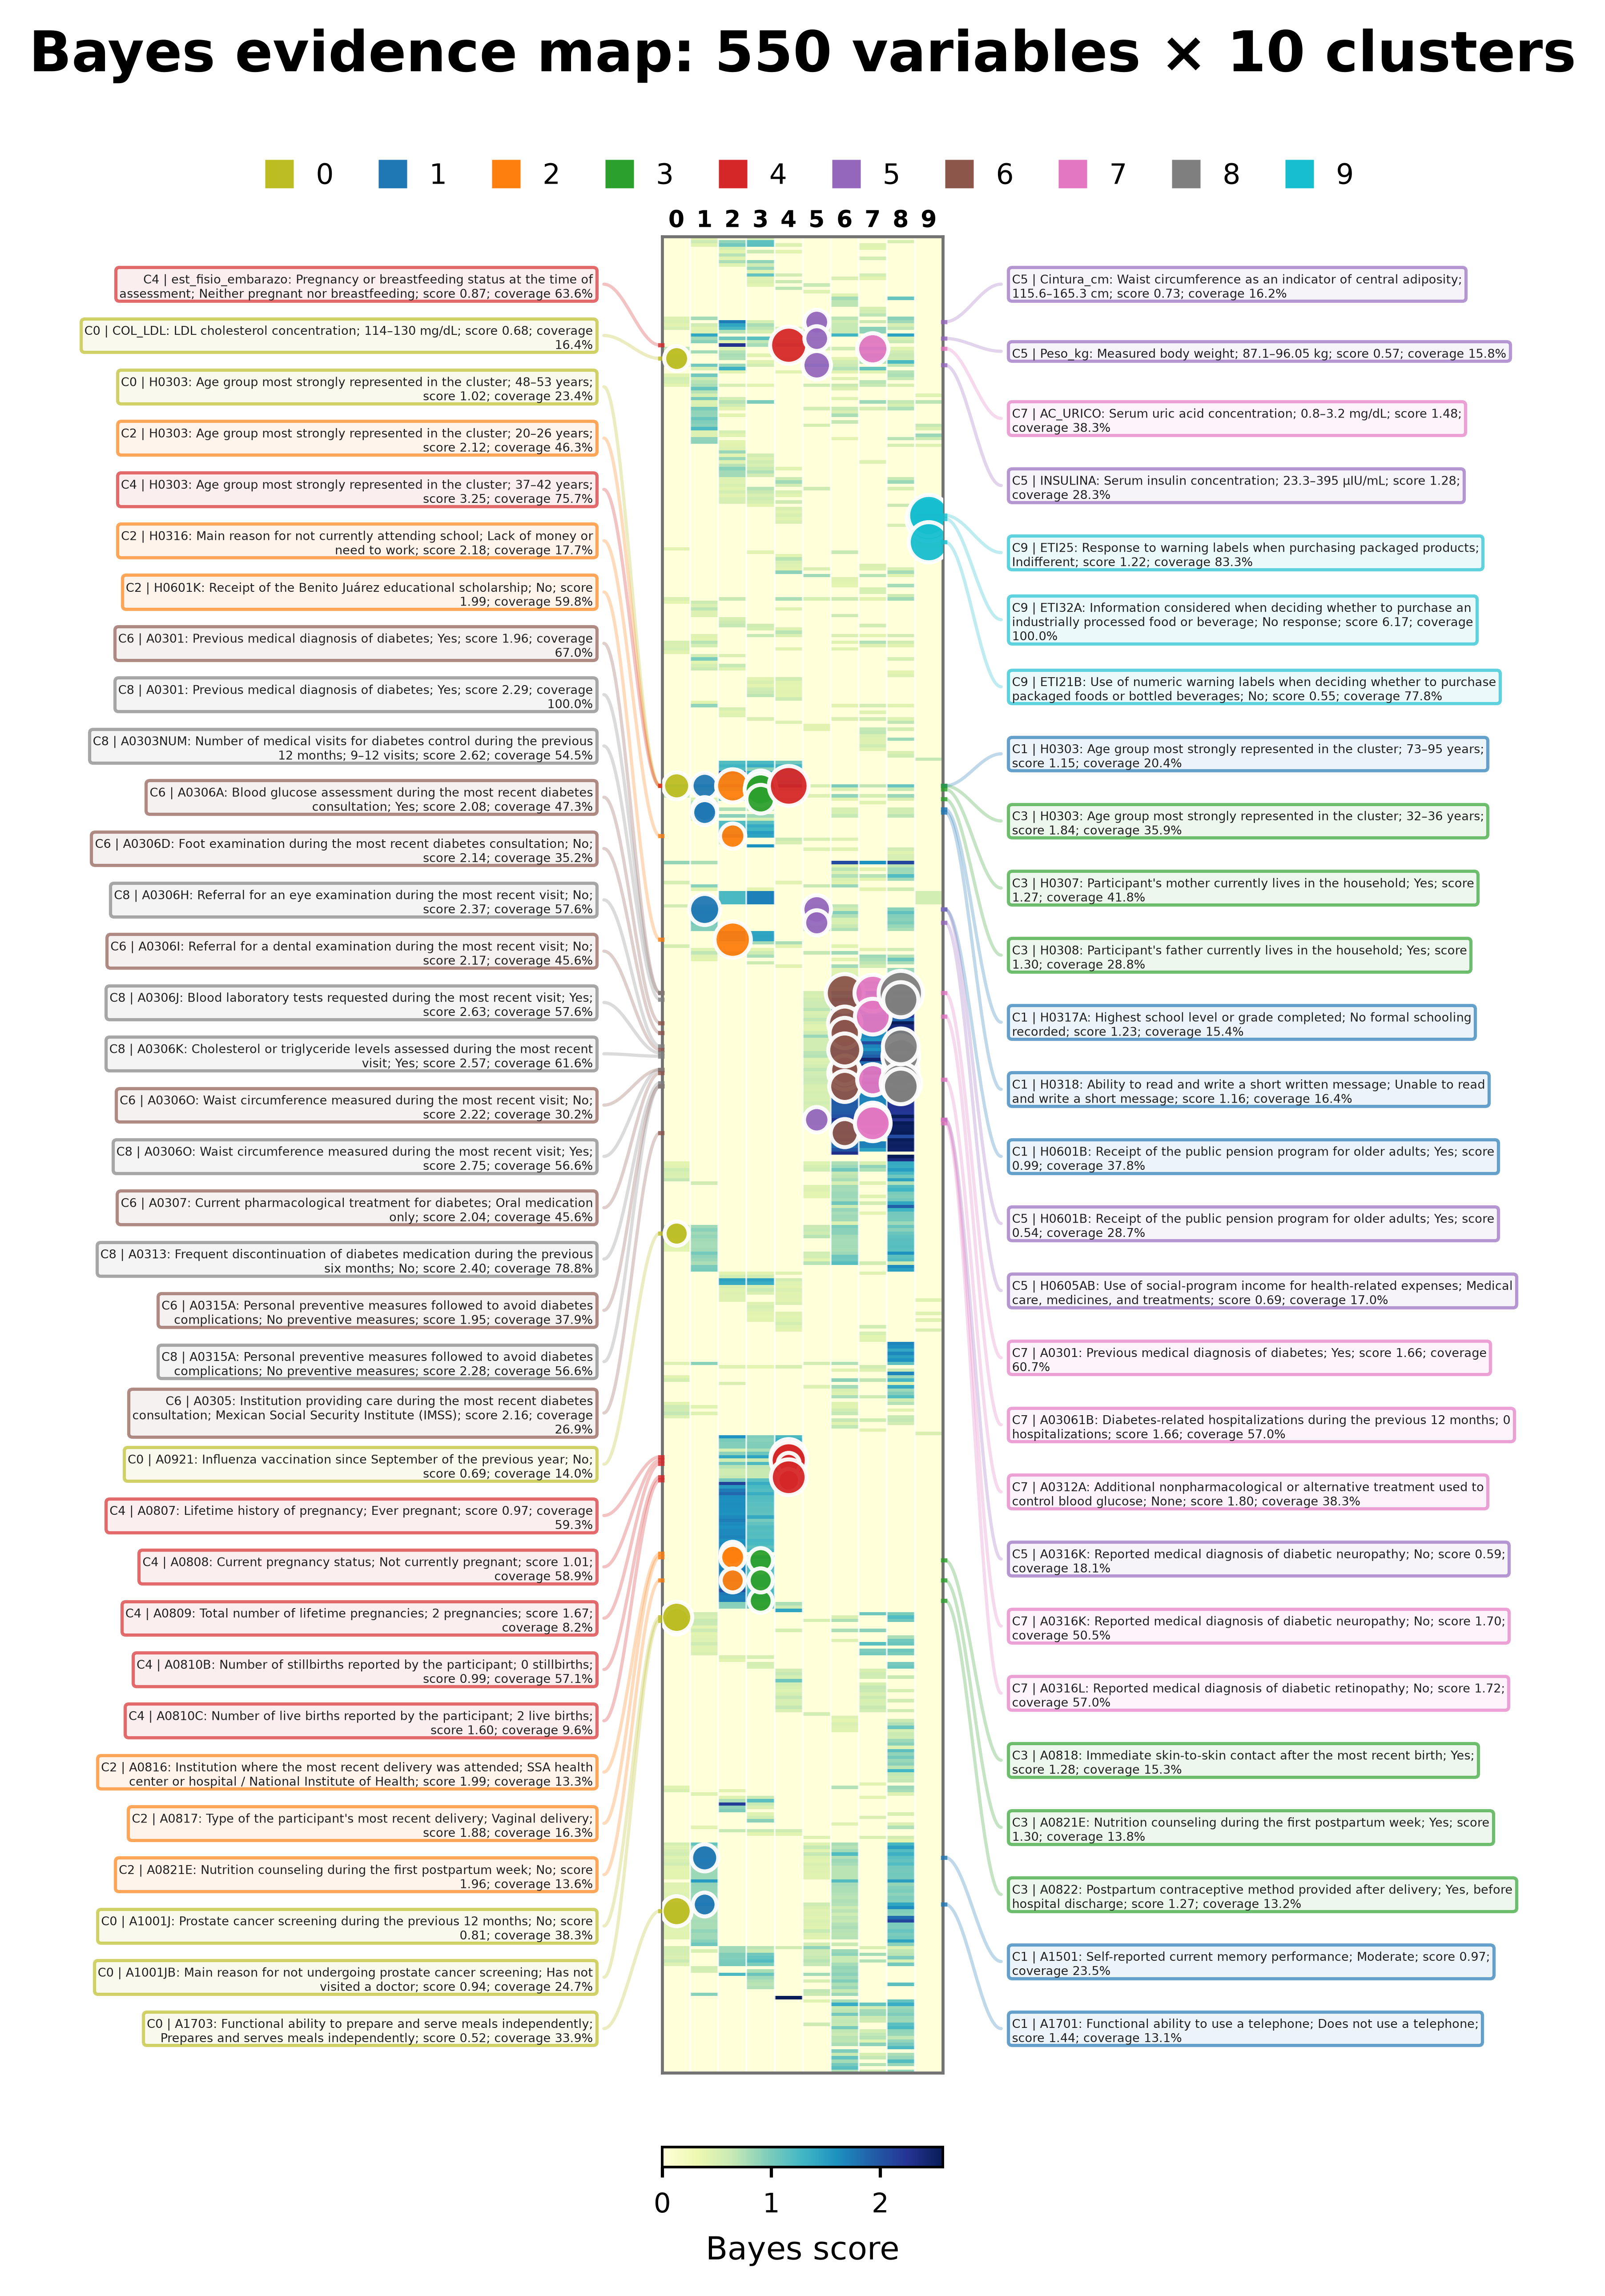

,heatmap_variables,clusters,cluster_order,manual_annotations,figure
0,550,10,C0 → C1 → C2 → C3 → C4 → C5 → C6 → C7 → C8 → C9,62,/Users/cristianjuliocesarpadronmanrique/Deskto...


In [9]:
# Exact modular port of the original supervised heatmap pipeline.
from ensanut_hba1c.workflows.nb_evidence import NBFilterConfig, load_nb_evidence
from ensanut_hba1c.workflows.supervised_heatmap import (
    SUPERVISED_HEATMAP_MODULE_VERSION,
    SupervisedHeatmapConfig,
    create_supervised_nb_heatmap,
)

print("Supervised heatmap module:", SUPERVISED_HEATMAP_MODULE_VERSION)

NB_FILTER_CONFIG = NBFilterConfig(
    min_n_cluster_x=10,
    min_score=0.40,
    min_coverage=0.07,
    sheet_name="NB_internal_operations",
)

NB_EVIDENCE = load_nb_evidence(
    OUTPUT_DIR / "bayes_internal_operations_all_variables.xlsx",
    config=NB_FILTER_CONFIG,
    prohibited_variables=sorted(set(
        REDUNDANT_AGE_COLUMNS + TARGET_DERIVED_COLUMNS
    )),
)

SUPERVISED_HEATMAP_RESULT = create_supervised_nb_heatmap(
    evidence=NB_EVIDENCE,
    supervised_input_df=SUPERVISED_INPUT_DF,
    output_dir=OUTPUT_DIR / "cluster_characterization_figures",
    config=SupervisedHeatmapConfig(
        # General figure geometry
        figure_height=8,
        dpi=int(globals().get("DPI", 650)),
        color_percentile=99.0,

        # Annotation text and boxes
        annotation_font_size=3,
        annotation_wrap_width=80,
        annotation_line_separation=0.5,
        annotation_outer_pad=0.02,
        annotation_border_pad=0.09,

        # Left panel, heatmap, and right panel
        left_text_width=2.0,
        left_connector_width=0.2,
        heatmap_width=1.0,
        right_connector_width=0.2,
        right_text_width=2.0,

        # Numeric cluster order and compact labels
        cluster_label_font_size=5.8,
        cluster_label_pad=1.0,
        show_cluster_prefix=False,
        legend_show_cluster_prefix=False,
        legend_font_size=7.0,

        # Compact Bayes-score colorbar
        colorbar_height=0.14,
        colorbar_width_fraction=0.45,
        colorbar_label_font_size=8.0,
        colorbar_tick_font_size=6.8,

        # Visual style and notebook preview
        cmap='YlGnBu',#"YlGnBu",
        show_filter_summary=False,
        show_in_notebook=True,
        notebook_preview_mode="saved_png",
        notebook_preview_width=1500,
        verbose=False,
    ),
)

# Shared objects used by XGBoost and optional exploratory cells.
evidence_df = NB_EVIDENCE.evidence_df
filtered_evidence_df = NB_EVIDENCE.filtered_evidence_df
score_matrix = NB_EVIDENCE.score_matrix
coverage_matrix = NB_EVIDENCE.coverage_matrix
count_matrix = NB_EVIDENCE.count_matrix
category_matrix = NB_EVIDENCE.category_matrix
VARIABLE_ORDER = NB_EVIDENCE.variable_order
CLUSTER_ORDER = SUPERVISED_HEATMAP_RESULT.cluster_order
MIN_N_CLUSTER_X = NB_FILTER_CONFIG.min_n_cluster_x
MIN_SCORE = NB_FILTER_CONFIG.min_score
MIN_COVERAGE = NB_FILTER_CONFIG.min_coverage

display(pd.DataFrame([{
    "heatmap_variables": SUPERVISED_HEATMAP_RESULT.n_variables,
    "clusters": SUPERVISED_HEATMAP_RESULT.n_clusters,
    "cluster_order": " → ".join(CLUSTER_ORDER),
    "manual_annotations": len(SUPERVISED_HEATMAP_RESULT.annotation_table),
    "figure": str(SUPERVISED_HEATMAP_RESULT.png_path),
}]))

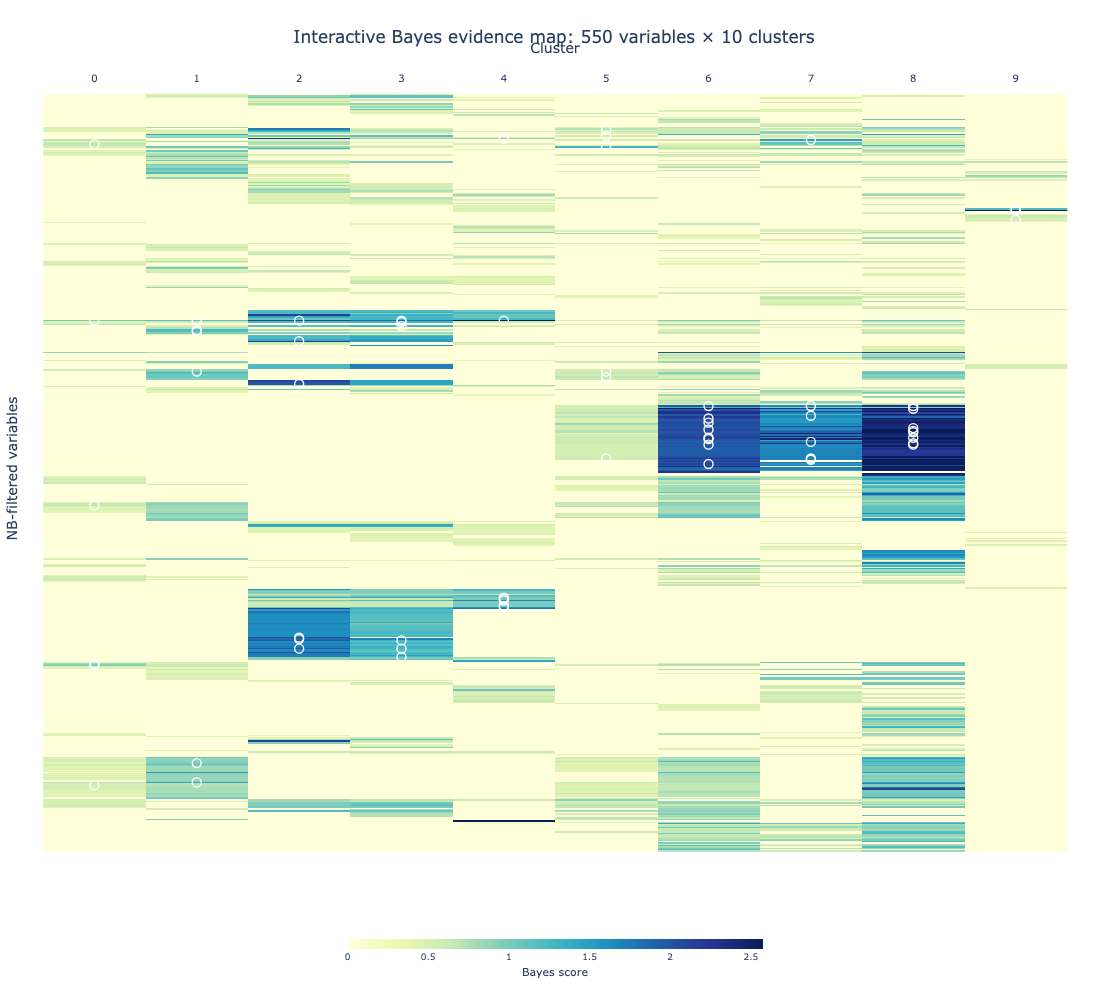

Interactive heatmap saved to: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/cluster_characterization_figures/interactive_nb_heatmap.html


In [10]:
# Interactive Plotly version of the NB heatmap.
# Requires:
#   NB_EVIDENCE
#   SUPERVISED_HEATMAP_RESULT
#
# This cell does not modify or replace the static Matplotlib/PDF heatmap.

from pathlib import Path
import re

import numpy as np
import pandas as pd
import plotly.graph_objects as go


# -------------------------------------------------------------------------
# Editable Plotly settings
# -------------------------------------------------------------------------
PLOTLY_HEATMAP_HEIGHT = 1000
PLOTLY_HEATMAP_WIDTH = 850

PLOTLY_COLOR_PERCENTILE = 99.0
PLOTLY_SHOW_VARIABLE_LABELS = False
PLOTLY_SHOW_MANUAL_ANNOTATION_MARKERS = True

PLOTLY_SAVE_HTML = True
PLOTLY_HTML_FILENAME = "interactive_nb_heatmap.html"


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def cluster_numeric_key(cluster):
    """Sort C0, C1, ..., C10 numerically instead of alphabetically."""
    text = str(cluster).strip()
    match = re.search(r"-?\d+", text)

    if match:
        return int(match.group())

    return 10**9


def normalize_text(value, fallback="Not available"):
    if value is None:
        return fallback

    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    text = str(value).strip()
    return text if text else fallback


# -------------------------------------------------------------------------
# Numeric cluster order
# -------------------------------------------------------------------------
cluster_order = sorted(
    [str(cluster) for cluster in NB_EVIDENCE.score_matrix.columns],
    key=cluster_numeric_key,
)

cluster_labels = [
    str(cluster_numeric_key(cluster))
    for cluster in cluster_order
]


# Preserve the complete NB-filtered variable order.
variable_order = list(NB_EVIDENCE.variable_order)


# -------------------------------------------------------------------------
# Reindex all matrices using the same variable and cluster order
# -------------------------------------------------------------------------
score_plot = (
    NB_EVIDENCE.score_matrix
    .reindex(index=variable_order, columns=cluster_order)
    .apply(pd.to_numeric, errors="coerce")
)

coverage_plot = (
    NB_EVIDENCE.coverage_matrix
    .reindex(index=variable_order, columns=cluster_order)
    .apply(pd.to_numeric, errors="coerce")
)

count_plot = (
    NB_EVIDENCE.count_matrix
    .reindex(index=variable_order, columns=cluster_order)
    .apply(pd.to_numeric, errors="coerce")
)

category_plot = (
    NB_EVIDENCE.category_matrix
    .reindex(index=variable_order, columns=cluster_order)
    .fillna("")
    .astype(str)
)


# -------------------------------------------------------------------------
# Manual annotation lookup
#
# This inserts into the hover information the English descriptions that
# previously appeared inside the side annotation boxes.
# -------------------------------------------------------------------------
annotation_table = (
    SUPERVISED_HEATMAP_RESULT.annotation_table.copy()
)

annotation_table["cluster"] = annotation_table["cluster"].astype(str)
annotation_table["var"] = annotation_table["var"].astype(str)

annotation_lookup = {
    (row["var"], row["cluster"]): {
        "description": normalize_text(
            row.get("english_description"),
            fallback="No manual description",
        ),
        "category_override": normalize_text(
            row.get("category_en_override"),
            fallback="",
        ),
    }
    for _, row in annotation_table.iterrows()
}


# -------------------------------------------------------------------------
# Build hover information for every heatmap cell
# -------------------------------------------------------------------------
n_variables = len(variable_order)
n_clusters = len(cluster_order)

customdata = np.empty(
    (n_variables, n_clusters, 8),
    dtype=object,
)

for row_index, variable in enumerate(variable_order):
    for column_index, cluster in enumerate(cluster_order):

        score = score_plot.iloc[row_index, column_index]
        coverage = coverage_plot.iloc[row_index, column_index]
        count = count_plot.iloc[row_index, column_index]
        category = category_plot.iloc[row_index, column_index]

        annotation = annotation_lookup.get(
            (str(variable), str(cluster)),
            {},
        )

        description = annotation.get(
            "description",
            "No manual annotation selected",
        )

        category_override = annotation.get(
            "category_override",
            "",
        )

        displayed_category = (
            category_override
            if category_override
            else normalize_text(category)
        )

        customdata[row_index, column_index, :] = [
            str(variable),
            str(cluster),
            description,
            displayed_category,
            (
                f"{float(score):.3f}"
                if pd.notna(score)
                else "Not available"
            ),
            (
                f"{float(coverage):.1%}"
                if pd.notna(coverage)
                else "Not available"
            ),
            (
                f"{int(round(float(count))):,}"
                if pd.notna(count)
                else "Not available"
            ),
            (
                "Yes"
                if (str(variable), str(cluster)) in annotation_lookup
                else "No"
            ),
        ]


# -------------------------------------------------------------------------
# Color scale
# -------------------------------------------------------------------------
positive_scores = score_plot.to_numpy(dtype=float)
positive_scores = positive_scores[
    np.isfinite(positive_scores)
    & (positive_scores > 0)
]

if positive_scores.size == 0:
    raise ValueError(
        "The NB score matrix contains no positive values."
    )

zmax = float(
    np.nanpercentile(
        positive_scores,
        PLOTLY_COLOR_PERCENTILE,
    )
)

if not np.isfinite(zmax) or zmax <= 0:
    zmax = float(np.nanmax(positive_scores))


# -------------------------------------------------------------------------
# Interactive heatmap
# -------------------------------------------------------------------------
figure = go.Figure()

figure.add_trace(
    go.Heatmap(
        z=score_plot.to_numpy(dtype=float),
        x=cluster_labels,
        y=variable_order,
        customdata=customdata,
        colorscale="YlGnBu",
        zmin=0,
        zmax=zmax,
        colorbar=dict(
            title=dict(
                text="Bayes score",
                side="bottom",
            ),
            orientation="h",
            x=0.50,
            xanchor="center",
            y=-0.10,
            yanchor="top",
            len=0.42,
            thickness=10,
            tickfont=dict(size=9),
        ),
        hovertemplate=(
            "<b>Cluster %{customdata[1]}</b>"
            "<br><b>Variable:</b> %{customdata[0]}"
            "<br><b>Description:</b> %{customdata[2]}"
            "<br><b>Category / bin:</b> %{customdata[3]}"
            "<br><b>Bayes score:</b> %{customdata[4]}"
            "<br><b>Coverage:</b> %{customdata[5]}"
            "<br><b>n_cluster_x:</b> %{customdata[6]}"
            "<br><b>Manual annotation:</b> %{customdata[7]}"
            "<extra></extra>"
        ),
        hoverongaps=False,
    )
)


# -------------------------------------------------------------------------
# Overlay markers for the manually selected annotation cells
# -------------------------------------------------------------------------
if PLOTLY_SHOW_MANUAL_ANNOTATION_MARKERS:

    marker_x = []
    marker_y = []
    marker_customdata = []

    for _, row in annotation_table.iterrows():

        cluster = str(row["cluster"])
        variable = str(row["var"])

        if (
            cluster not in cluster_order
            or variable not in variable_order
        ):
            continue

        marker_x.append(
            str(cluster_numeric_key(cluster))
        )
        marker_y.append(variable)

        marker_customdata.append([
            cluster,
            variable,
            normalize_text(
                row.get("english_description"),
                fallback="No manual description",
            ),
            normalize_text(
                row.get("category_en_override"),
            ),
            f"{float(row['score']):.3f}",
            f"{float(row['coverage']):.1%}",
        ])

    figure.add_trace(
        go.Scatter(
            x=marker_x,
            y=marker_y,
            mode="markers",
            marker=dict(
                symbol="circle-open",
                size=9,
                line=dict(width=1.4),
                color="white",
            ),
            customdata=np.asarray(
                marker_customdata,
                dtype=object,
            ),
            hovertemplate=(
                "<b>Selected manual annotation</b>"
                "<br><b>Cluster:</b> %{customdata[0]}"
                "<br><b>Variable:</b> %{customdata[1]}"
                "<br><b>Description:</b> %{customdata[2]}"
                "<br><b>Category / bin:</b> %{customdata[3]}"
                "<br><b>Bayes score:</b> %{customdata[4]}"
                "<br><b>Coverage:</b> %{customdata[5]}"
                "<extra></extra>"
            ),
            name="Selected annotations",
            showlegend=False,
        )
    )


# -------------------------------------------------------------------------
# Layout
# -------------------------------------------------------------------------
figure.update_layout(
    title=dict(
        text=(
            "Interactive Bayes evidence map: "
            f"{n_variables:,} variables × {n_clusters} clusters"
        ),
        x=0.5,
        xanchor="center",
    ),
    width=PLOTLY_HEATMAP_WIDTH,
    height=PLOTLY_HEATMAP_HEIGHT,
    margin=dict(
        l=90 if PLOTLY_SHOW_VARIABLE_LABELS else 35,
        r=35,
        t=85,
        b=120,
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    hoverlabel=dict(
        align="left",
        font_size=12,
    ),
)

figure.update_xaxes(
    title_text="Cluster",
    side="top",
    tickmode="array",
    tickvals=cluster_labels,
    ticktext=cluster_labels,
    tickfont=dict(size=10),
    showgrid=False,
    zeroline=False,
)

figure.update_yaxes(
    title_text="NB-filtered variables",
    autorange="reversed",
    showticklabels=PLOTLY_SHOW_VARIABLE_LABELS,
    tickfont=dict(size=7),
    showgrid=False,
    zeroline=False,
)


# -------------------------------------------------------------------------
# Display and optional HTML export
# -------------------------------------------------------------------------
figure.show(
    config={
        "displaylogo": False,
        "scrollZoom": True,
        "responsive": True,
        "toImageButtonOptions": {
            "format": "png",
            "filename": "interactive_nb_heatmap",
            "scale": 2,
        },
    }
)

if PLOTLY_SAVE_HTML:
    plotly_output_dir = (
        OUTPUT_DIR
        / "cluster_characterization_figures"
    )

    plotly_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    plotly_html_path = (
        plotly_output_dir
        / PLOTLY_HTML_FILENAME
    )

    figure.write_html(
        plotly_html_path,
        include_plotlyjs="cdn",
        full_html=True,
        config={
            "displaylogo": False,
            "scrollZoom": True,
            "responsive": True,
        },
    )

    print(
        "Interactive heatmap saved to:",
        plotly_html_path,
    )

## 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics

The signed Bayes analysis above may use intervals to characterize communities, but the final cluster classifier in this section does **not** receive those bins or binary rules.

- Source variables are restricted to the variables retained by the numerical NB heatmap filter.
- `HB1AC`, `GLU_SUERO`, target-derived variables, identifiers, and technical fields are excluded.
- Numerical values are passed through the project model-matrix preparation without quantile binning.
- Textual missing/non-response categories are replaced with `NaN` before matrix preparation.
- Native missing values remain missing; no explicit missing-category predictors are created.
- All OOF metrics come from nested cross-validation and remain an internal label-recoverability audit.


In [11]:
# Editable raw-variable XGBoost and diagnostic settings.
RUN_XGBOOST_CROSS_VALIDATION = True
RUN_OPTUNA_HYPERPARAMETER_SEARCH = True

# -----------------------------------------------------------------------------
# Raw source-variable representation
# -----------------------------------------------------------------------------
RAW_SOURCE_VARIABLE_SET = "nb_filtered_variables"
RAW_MAX_PREDICTORS = None
RAW_MAX_CATEGORICAL_LEVELS = 100

# Text labels treated as missing/non-response and converted to NaN before
# prepare_model_matrix. Numeric special codes are not guessed because their
# meaning is questionnaire-specific.
RAW_EXCLUDE_MISSING_LIKE_CATEGORIES = True
RAW_MISSING_CATEGORY_TOKENS = {
    "", "missing", "miss", "na", "n/a", "nan", "none", "null", "<na>",
    "sin dato", "sin datos", "dato faltante", "datos faltantes",
    "no aplica", "no aplicable", "no disponible", "no especificado",
    "no sabe", "no responde", "no respuesta", "no contesta", "no contesto",
    "ns", "nr", "ns/nr", "ignorado", "desconocido", "unknown",
    "not applicable", "not available", "not reported", "refused", "rechazo",
}

# Second safety barrier. These are removed even if an earlier evidence workbook
# was created before the exclusion cell was updated.
XGB_NON_GLYCEMIC_EXCLUSIONS = sorted(set(
    NB_FRAMEWORK_EXCLUDE_VARIABLES
    + NOTEBOOK2_EXCLUDE_VARIABLES
    + AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS
    + [CLUSTER_COLUMN, "HB1AC", "GLU_SUERO", "_merge"]
))

XGB_CV_N_SPLITS = 5
XGB_RANDOM_STATE = 42

OPTUNA_INNER_CV_SPLITS = 2
OPTUNA_TRIALS_PER_OUTER_FOLD = 8
OPTUNA_FINAL_N_TRIALS = 5
OPTUNA_TIMEOUT_SECONDS = None

OPTUNA_STUDY_BASENAME = "xgboost_raw_variables_no_glucose"
OPTUNA_REUSE_EXISTING_STUDIES = True

OPTUNA_N_STARTUP_TRIALS = 4
OPTUNA_PRUNER_STARTUP_TRIALS = 3
OPTUNA_PRUNER_WARMUP_STEPS = 1
OPTUNA_OBJECTIVE_METRIC = "macro_f1"
OPTUNA_N_JOBS = 1

XGB_MAX_ESTIMATORS = 1000
XGB_EARLY_STOPPING_ROUNDS = 100
XGB_TREE_METHOD = "hist"
XGB_N_JOBS = -1
XGB_USE_BALANCED_CLASS_WEIGHTS = True

OPTUNA_LEARNING_RATE_MIN = 0.01
OPTUNA_LEARNING_RATE_MAX = 0.20
OPTUNA_MAX_DEPTH_MIN = 3
OPTUNA_MAX_DEPTH_MAX = 12
OPTUNA_MIN_CHILD_WEIGHT_MIN = 0.5
OPTUNA_MIN_CHILD_WEIGHT_MAX = 20.0
OPTUNA_SUBSAMPLE_MIN = 0.60
OPTUNA_SUBSAMPLE_MAX = 1.00
OPTUNA_COLSAMPLE_BYTREE_MIN = 0.50
OPTUNA_COLSAMPLE_BYTREE_MAX = 1.00
OPTUNA_GAMMA_MIN = 1e-8
OPTUNA_GAMMA_MAX = 10.0
OPTUNA_REG_ALPHA_MIN = 1e-8
OPTUNA_REG_ALPHA_MAX = 10.0
OPTUNA_REG_LAMBDA_MIN = 0.10
OPTUNA_REG_LAMBDA_MAX = 50.0
OPTUNA_MAX_BIN_OPTIONS = [128, 256, 512]
OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS = [1, 4, 8, 16]
OPTUNA_MAX_CAT_THRESHOLD_OPTIONS = [16, 32, 64, 128]

XGB_SHAP_MAX_ROWS_PER_FOLD = 300
XGB_TOP_FEATURES_GLOBAL = 60
XGB_TOP_FEATURES_PER_CLUSTER = 30
XGB_TOP_CONFUSION_PAIRS = 20
XGB_TOP_OPTUNA_PARAMETERS = 15
XGB_CALIBRATION_BINS = 10
XGB_REPORT_DPI = 200
XGB_SAVE_INDIVIDUAL_PLOTS = True
XGB_SHOW_ALL_DIAGNOSTIC_FIGURES = True

XGB_SHOW_PROGRESS_BARS = True
XGB_PROGRESS_LEAVE = True


In [12]:
if RUN_XGBOOST_CROSS_VALIDATION:
    import re
    import unicodedata

    import numpy as np
    import pandas as pd
    from pandas.api.types import is_numeric_dtype

    from ensanut_hba1c.io import load_ensanut_inputs
    from ensanut_hba1c.modeling import prepare_model_matrix
    from ensanut_hba1c.workflows.cluster_dataset import (
        ClusterDatasetConfig,
        prepare_cluster_dataset,
    )
    from ensanut_hba1c.workflows.progress import TaskProgress

    def _normalise_missing_category_token(value):
        """Normalize a category label for exact missing/non-response matching."""
        text = unicodedata.normalize("NFKD", str(value))
        text = text.encode("ascii", "ignore").decode("ascii")
        text = re.sub(r"\s+", " ", text).strip().lower()
        return text

    _RAW_NORMALIZED_MISSING_TOKENS = {
        _normalise_missing_category_token(token)
        for token in RAW_MISSING_CATEGORY_TOKENS
    }

    def replace_missing_like_categories_with_nan(
        frame,
        columns,
        *,
        normalized_missing_tokens,
    ):
        """Replace exact textual missing/non-response categories with NaN.

        Numeric columns are left untouched. Numeric special codes such as 9, 99,
        or 999 are not inferred here because their interpretation is variable-
        and questionnaire-specific.
        """
        cleaned = frame.copy()
        audit_rows = []

        for column in columns:
            if column not in cleaned.columns:
                continue

            series = cleaned[column]
            if is_numeric_dtype(series):
                continue

            normalized = (
                series.astype("string")
                .map(
                    lambda value: (
                        pd.NA
                        if pd.isna(value)
                        else _normalise_missing_category_token(value)
                    )
                )
            )
            mask = normalized.isin(normalized_missing_tokens).fillna(False)
            n_replaced = int(mask.sum())

            if n_replaced:
                original_counts = (
                    series.loc[mask]
                    .astype("string")
                    .value_counts(dropna=False)
                    .to_dict()
                )
                cleaned.loc[mask, column] = np.nan
                audit_rows.append({
                    "source_variable": column,
                    "n_replaced_with_nan": n_replaced,
                    "original_labels": " | ".join(
                        f"{key}: {value}"
                        for key, value in original_counts.items()
                    ),
                })

        audit = pd.DataFrame(
            audit_rows,
            columns=[
                "source_variable",
                "n_replaced_with_nan",
                "original_labels",
            ],
        )
        return cleaned, audit

    XGB_TASK_PROGRESS = TaskProgress(
        tasks=(
            "Load ENSANUT inputs",
            "Remove textual missing/non-response categories",
            "Prepare raw non-glycemic model matrix",
            "Run nested CV, Optuna, and SHAP",
            "Export metrics and diagnostic figures",
        ),
        description="Raw-variable XGBoost workflow",
        enabled=XGB_SHOW_PROGRESS_BARS,
        leave=XGB_PROGRESS_LEAVE,
        position=0,
    )

    XGB_TASK_PROGRESS.set_stage("load ENSANUT inputs")
    ensanut_df, model_dictionary_df = load_ensanut_inputs(
        PATHS.input_dir,
        data_filename="ENSANUT_2024_mx.csv",
        dictionary_filename="ENSANUT_2024.csv",
    )
    XGB_TASK_PROGRESS.complete("inputs loaded")

    if RAW_SOURCE_VARIABLE_SET != "nb_filtered_variables":
        raise ValueError(
            "Only RAW_SOURCE_VARIABLE_SET='nb_filtered_variables' is "
            "implemented in this publication notebook."
        )

    _nb_filtered_variables = list(
        getattr(
            SUPERVISED_HEATMAP_RESULT,
            "filtered_variables",
            getattr(NB_EVIDENCE, "variable_order", []),
        )
    )
    _forbidden = set(XGB_NON_GLYCEMIC_EXCLUSIONS)
    RAW_SOURCE_VARIABLES = [
        variable
        for variable in _nb_filtered_variables
        if variable in ensanut_df.columns
        and variable not in _forbidden
    ]

    forbidden_selected = sorted(set(RAW_SOURCE_VARIABLES).intersection(_forbidden))
    if forbidden_selected:
        raise AssertionError(
            f"Forbidden source variables entered the raw matrix: {forbidden_selected}"
        )
    if "GLU_SUERO" in RAW_SOURCE_VARIABLES:
        raise AssertionError("GLU_SUERO must not enter the raw-variable classifier.")
    if "HB1AC" in RAW_SOURCE_VARIABLES:
        raise AssertionError("HB1AC must not enter the raw-variable classifier.")

    XGB_TASK_PROGRESS.set_stage("remove missing/non-response categories")
    if RAW_EXCLUDE_MISSING_LIKE_CATEGORIES:
        ENSANUT_RAW_XGB_DF, RAW_MISSING_CATEGORY_AUDIT = (
            replace_missing_like_categories_with_nan(
                ensanut_df,
                RAW_SOURCE_VARIABLES,
                normalized_missing_tokens=_RAW_NORMALIZED_MISSING_TOKENS,
            )
        )
    else:
        ENSANUT_RAW_XGB_DF = ensanut_df.copy()
        RAW_MISSING_CATEGORY_AUDIT = pd.DataFrame(
            columns=[
                "source_variable",
                "n_replaced_with_nan",
                "original_labels",
            ]
        )
    XGB_TASK_PROGRESS.complete("missing categories removed")

    MODEL_EXCLUDE_COLUMNS = sorted(set(
        REDUNDANT_AGE_COLUMNS
        + TARGET_DERIVED_COLUMNS
        + DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + ["HB1AC", "GLU_SUERO", "_merge"]
    ))
    FORBIDDEN_PREDICTORS = sorted(set(
        NB_FRAMEWORK_EXCLUDE_VARIABLES
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS
        + list(ID_COLUMNS)
        + [CLUSTER_COLUMN, "HB1AC", "GLU_SUERO", "_merge"]
    ))

    XGB_TASK_PROGRESS.set_stage("prepare raw non-glycemic predictors")
    PREPARED_RAW_CLUSTER_DATASET = prepare_cluster_dataset(
        ENSANUT_RAW_XGB_DF,
        cluster_df,
        prepare_model_matrix_fn=prepare_model_matrix,
        evidence=NB_EVIDENCE,
        config=ClusterDatasetConfig(
            target_column_for_cohort="HB1AC",
            weight_column=None,
            id_columns=tuple(ID_COLUMNS),
            cluster_column=CLUSTER_COLUMN,
            max_categorical_levels=RAW_MAX_CATEGORICAL_LEVELS,
            max_nb_features=RAW_MAX_PREDICTORS,
        ),
        model_exclude_columns=MODEL_EXCLUDE_COLUMNS,
        forbidden_predictors=FORBIDDEN_PREDICTORS,
    )

    X_RAW_CLUSTER = PREPARED_RAW_CLUSTER_DATASET.X.copy()
    RAW_Y = PREPARED_RAW_CLUSTER_DATASET.y.copy()
    RAW_PARTICIPANT_KEYS = PREPARED_RAW_CLUSTER_DATASET.participant_keys.copy()

    _raw_weights = PREPARED_RAW_CLUSTER_DATASET.sample_weights
    if _raw_weights is None:
        RAW_SAMPLE_WEIGHTS = np.ones(len(RAW_Y), dtype=float)
    else:
        RAW_SAMPLE_WEIGHTS = np.asarray(_raw_weights, dtype=float).reshape(-1)

    if X_RAW_CLUSTER.empty:
        raise RuntimeError(
            "The raw XGBoost matrix is empty. Review exclusions and the NB "
            "filtered-variable set."
        )

    # The final model matrix must contain original source-variable columns,
    # never binary interval-rule columns.
    binary_rule_like_columns = [
        column
        for column in X_RAW_CLUSTER.columns
        if re.match(r"^R\d+__", str(column))
    ]
    if binary_rule_like_columns:
        raise AssertionError(
            "Binary-rule columns were detected in the raw-variable matrix: "
            f"{binary_rule_like_columns[:20]}"
        )

    forbidden_in_matrix = sorted(
        set(map(str, X_RAW_CLUSTER.columns)).intersection(_forbidden)
    )
    if forbidden_in_matrix:
        raise AssertionError(
            "Forbidden variables were detected in the final raw matrix: "
            f"{forbidden_in_matrix}"
        )

    assert set(X_RAW_CLUSTER.columns).issubset(
        set(SUPERVISED_HEATMAP_RESULT.filtered_variables)
    ), "XGBoost contains variables outside the NB-filtered source-variable set."

    XGB_TASK_PROGRESS.complete("raw model matrix ready")

    RAW_OUTPUT_DIR = (
        PATHS.notebook2_results
        / "xgboost_cluster_classification_raw_no_glucose"
    )
    RAW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    RAW_MISSING_CATEGORY_AUDIT.to_csv(
        RAW_OUTPUT_DIR / "textual_missing_categories_replaced_with_nan.csv",
        index=False,
    )

    RAW_REPRESENTATION_AUDIT = pd.DataFrame([{
        "representation": "raw_source_variables",
        "participants": len(X_RAW_CLUSTER),
        "source_predictors": X_RAW_CLUSTER.shape[1],
        "clusters": RAW_Y.nunique(),
        "uses_quantile_bins": False,
        "uses_binary_rules": False,
        "glucose_excluded": "GLU_SUERO" not in X_RAW_CLUSTER.columns,
        "hba1c_excluded": "HB1AC" not in X_RAW_CLUSTER.columns,
        "textual_missing_categories_modeled": False,
        "native_nan_retained": True,
    }])
    RAW_REPRESENTATION_AUDIT.to_csv(
        RAW_OUTPUT_DIR / "raw_representation_audit.csv",
        index=False,
    )

    display(RAW_REPRESENTATION_AUDIT)
    display(
        RAW_MISSING_CATEGORY_AUDIT
        .sort_values("n_replaced_with_nan", ascending=False)
        .head(30)
    )


Raw-variable XGBoost workflow:  60%|▌| 3/5 [00:05<00:02,  1.47s/task, raw model

,representation,participants,source_predictors,clusters,uses_quantile_bins,uses_binary_rules,glucose_excluded,hba1c_excluded,textual_missing_categories_modeled,native_nan_retained
0,raw_source_variables,2530,545,10,False,False,True,True,False,True


,source_variable,n_replaced_with_nan,original_labels


,X_rows,y_rows,sample_weight_rows,participant_key_rows
0,2530,2530,2530,2530


Raw-variable XGBoost workflow:  60%|▌| 3/5 [00:05<00:02,  1.47s/task, nested CV
XGBoost pipeline:   0%|      | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · Optuna]

Optuna · outer fold 1:   0%|                          | 0/8 [00:00<?, ?trial/s]

Optuna · outer fold 1:   0%| | 0/8 [00:00<?, ?trial/s, trial=1, inner fold=1/2]

Optuna · outer fold 1:   0%| | 0/8 [00:19<?, ?trial/s, trial=1, inner fold=2/2]

Optuna · outer fold 1:  12%|▏| 1/8 [00:39<04:35, 39.35s/trial, trial=1, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:39<04:35, 39.35s/trial, trial=1, score=0

Optuna · outer fold 1:  12%|▏| 1/8 [00:39<04:35, 39.35s/trial, trial=2, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:42<04:35, 39.35s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:44<01:56, 19.46s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:44<01:56, 19.46s/trial, trial=2, score=0

Optuna · outer fold 1:  25%|▎| 2/8 [00:44<01:56, 19.46s/trial, trial=3, inner f

Optuna · outer fold 1:  25%|▎

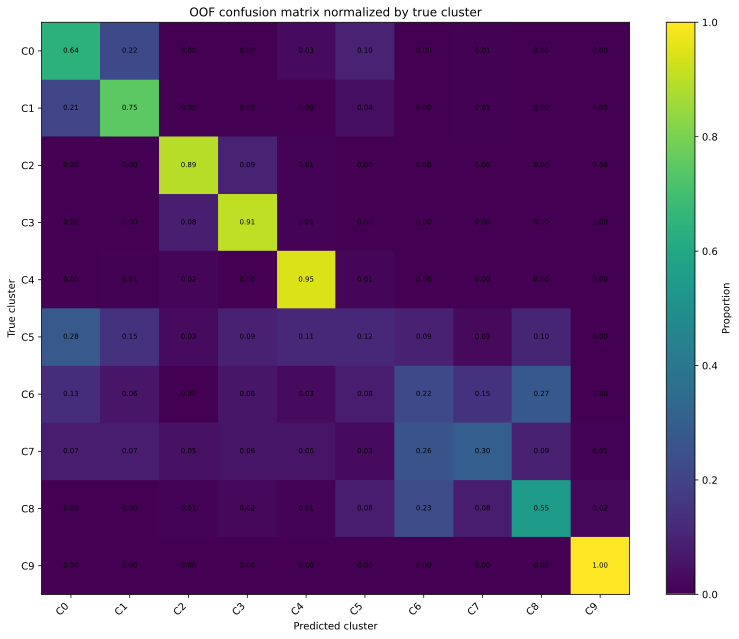

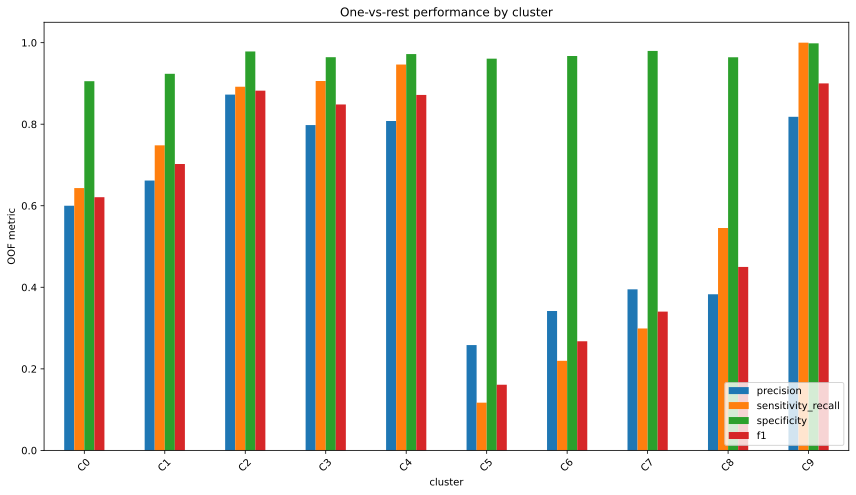

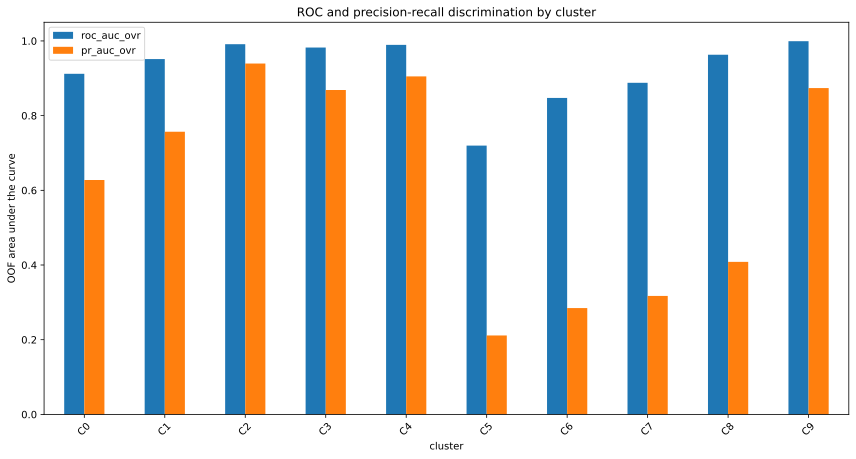

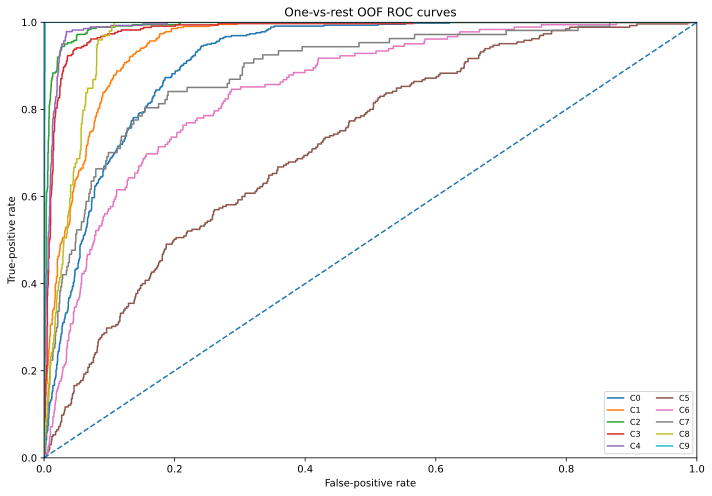

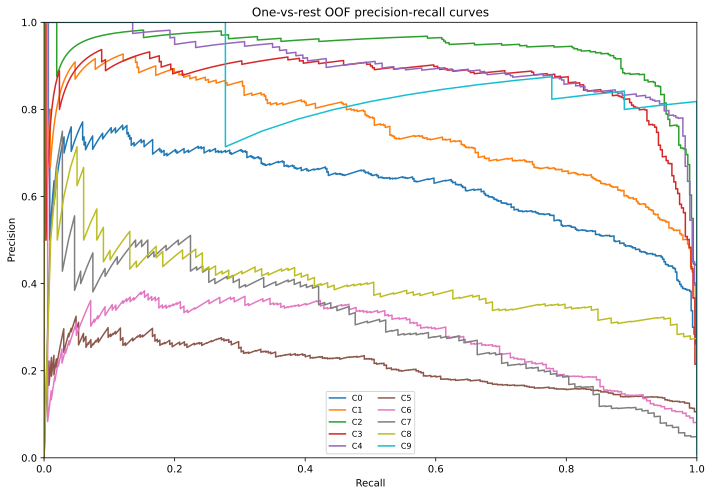

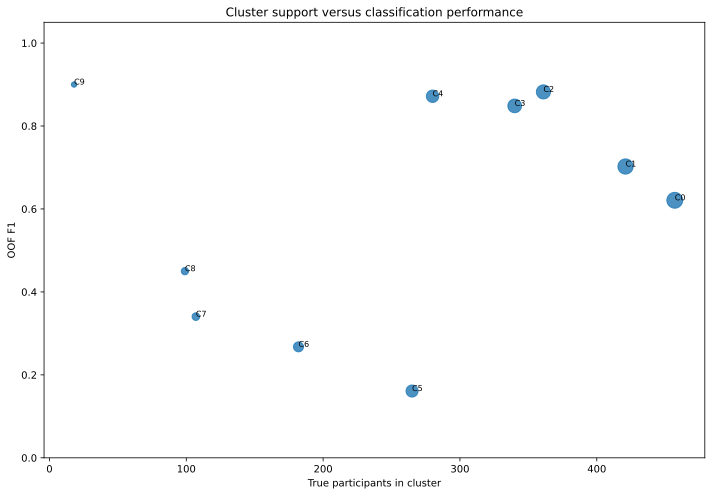

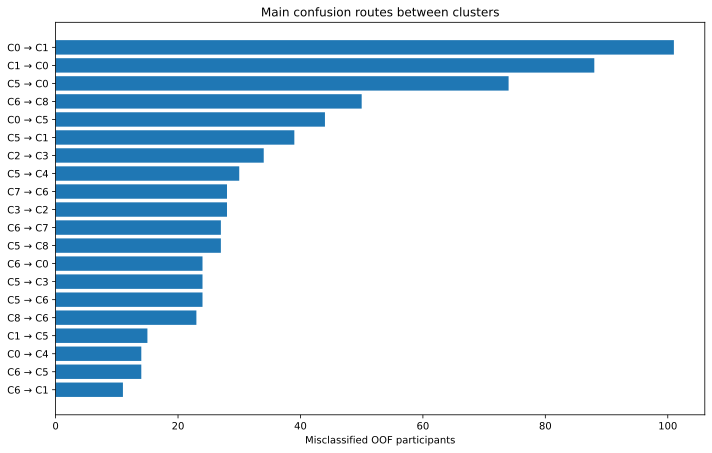

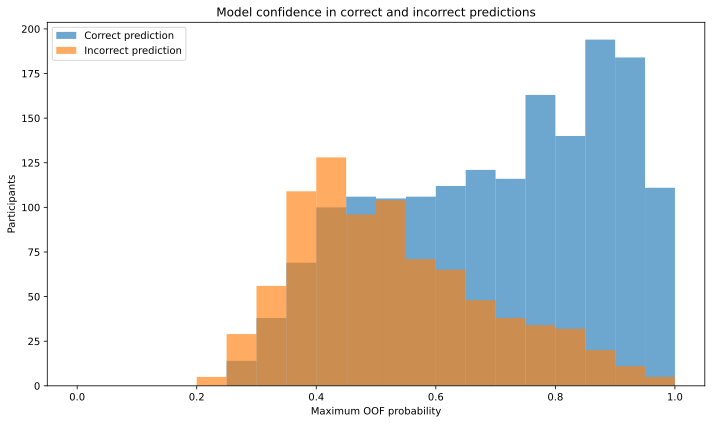

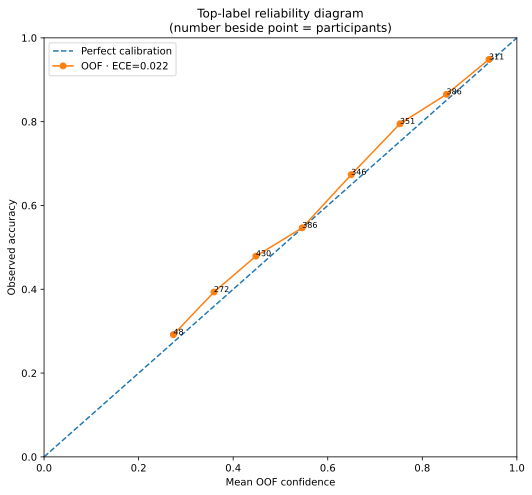

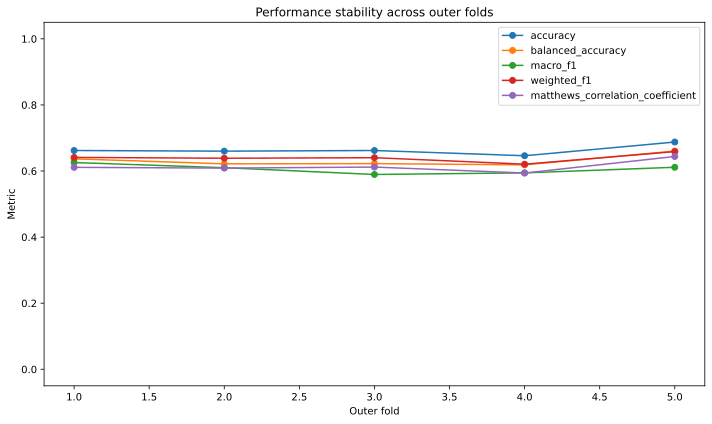

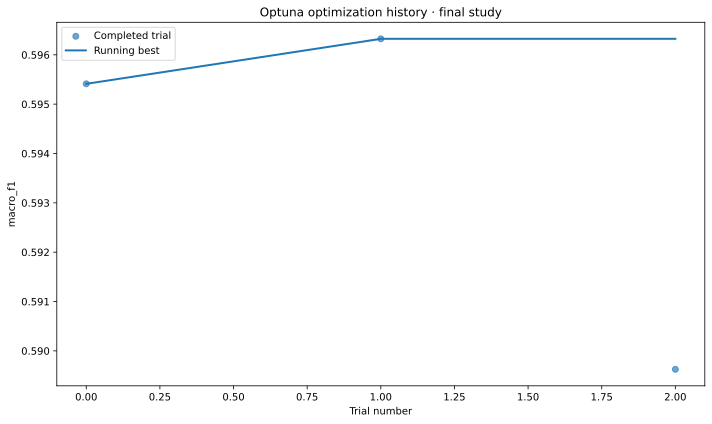

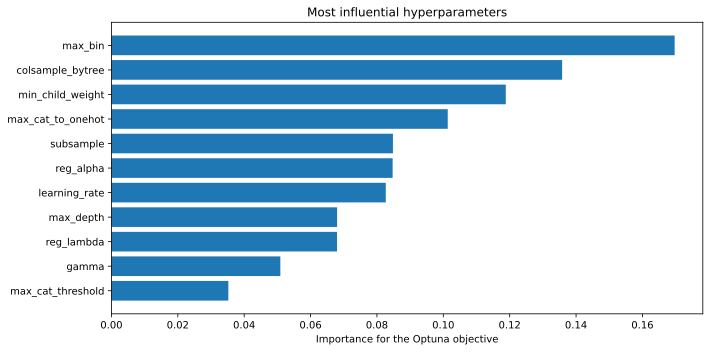

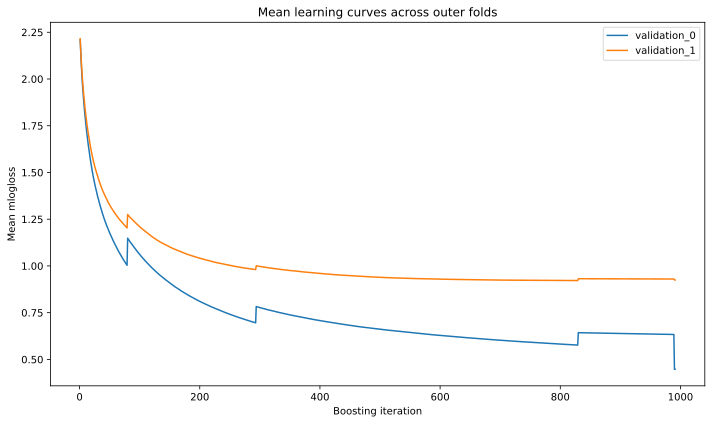

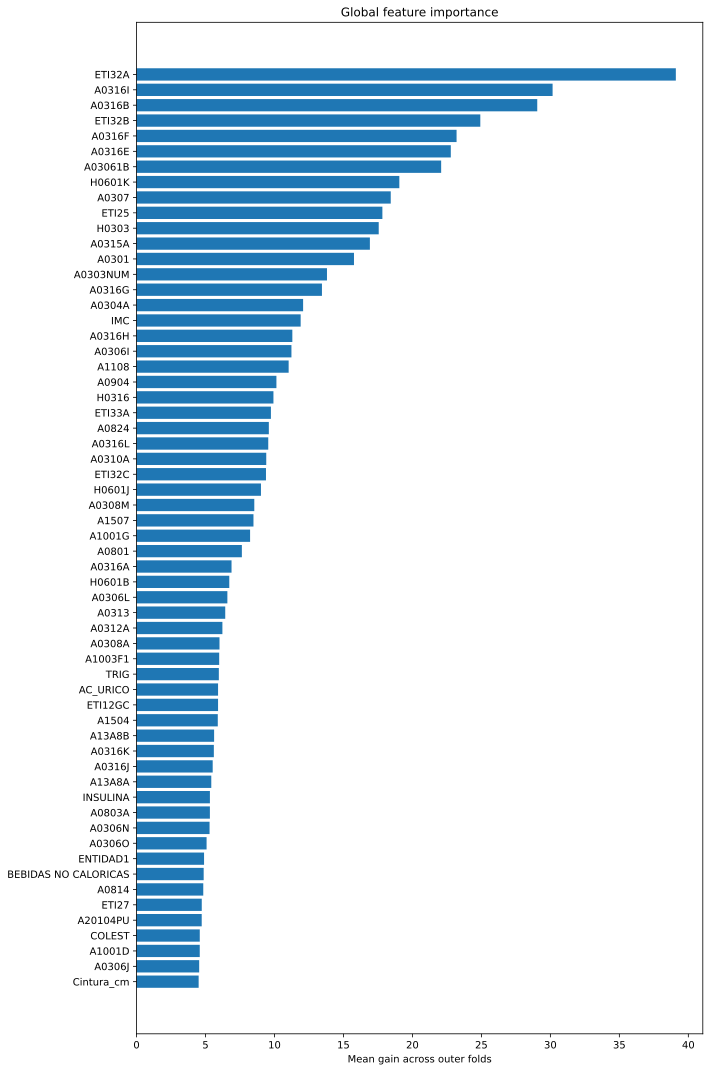

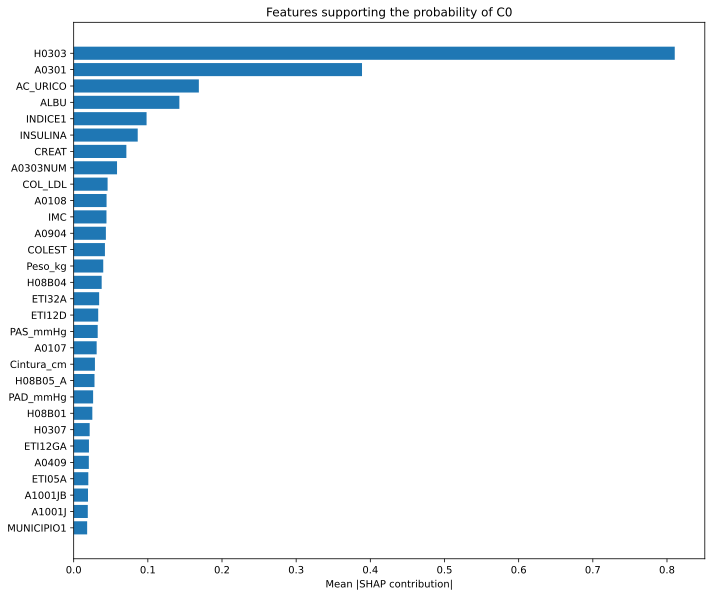

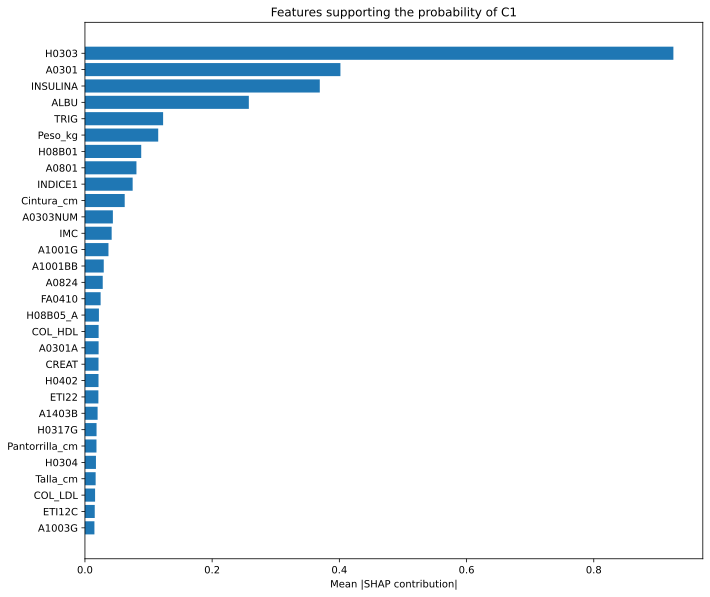

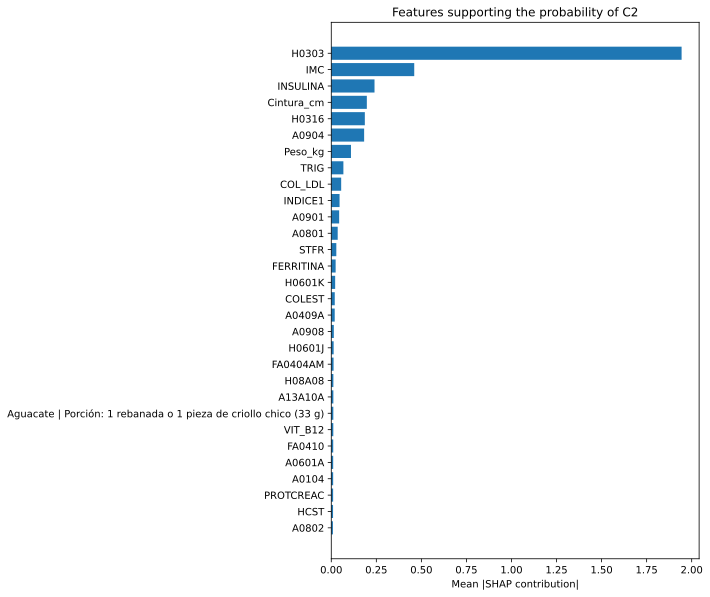

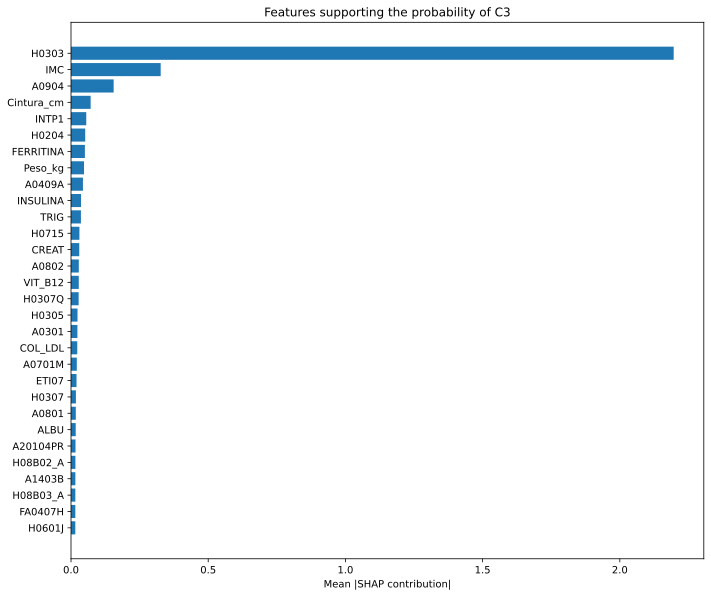

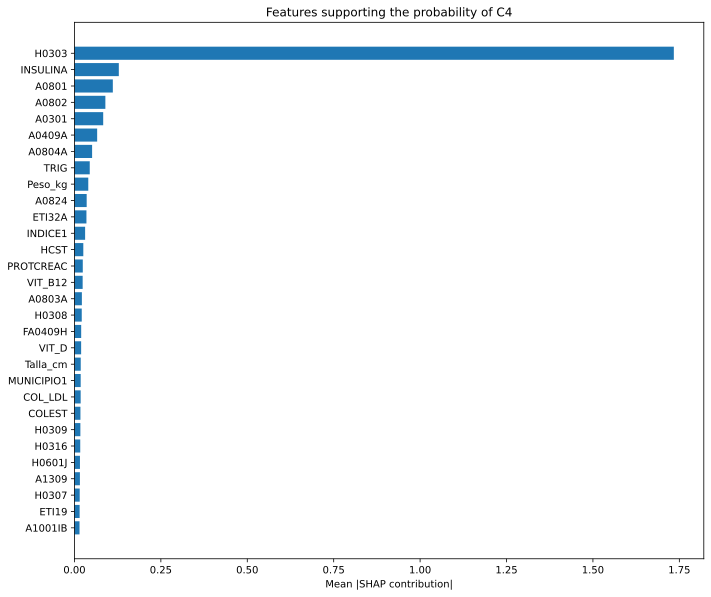

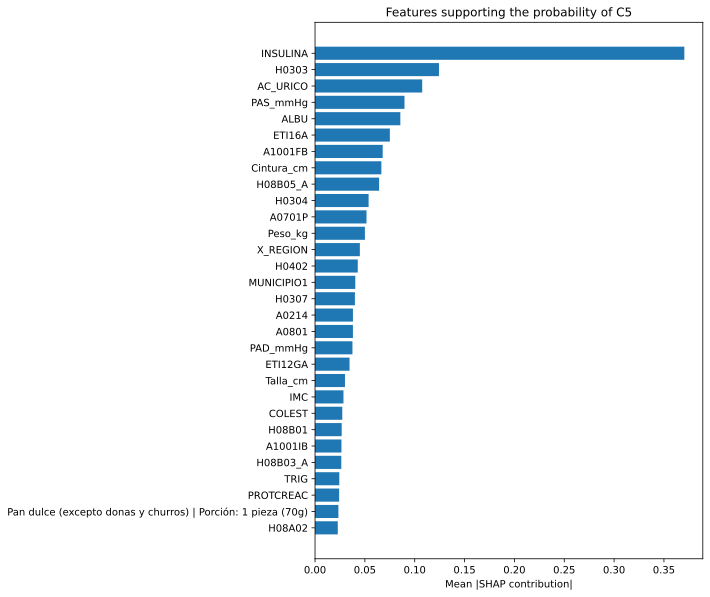

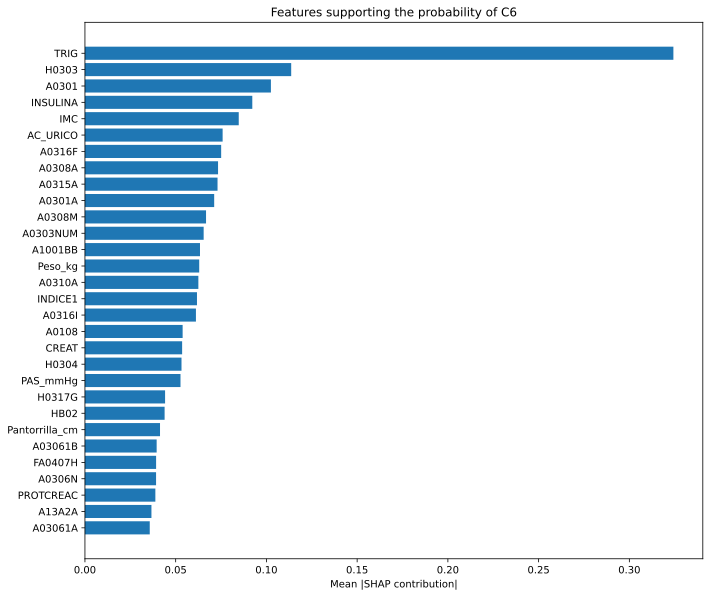

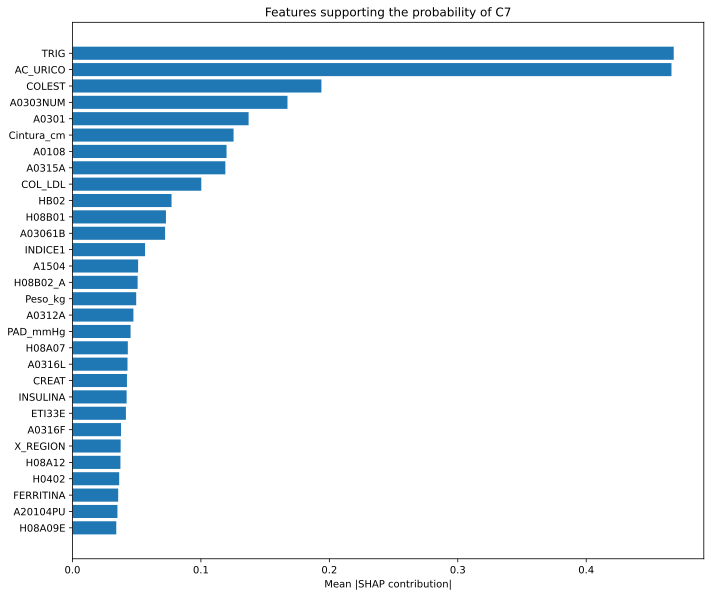

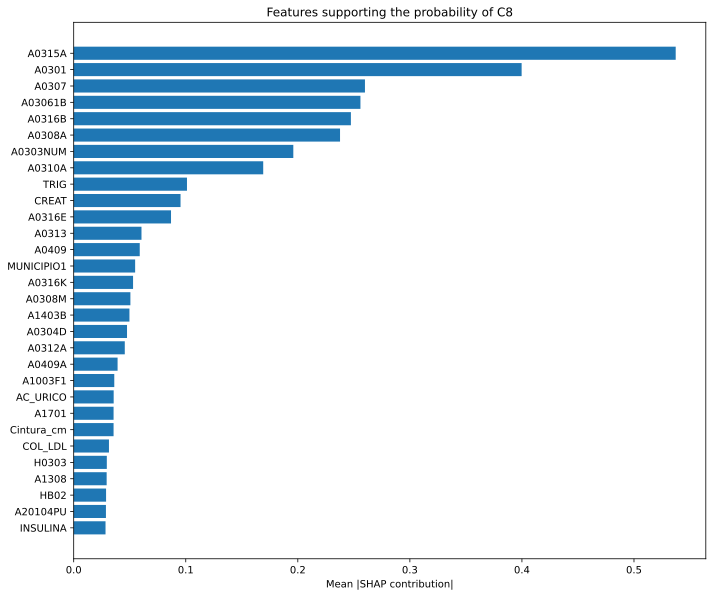

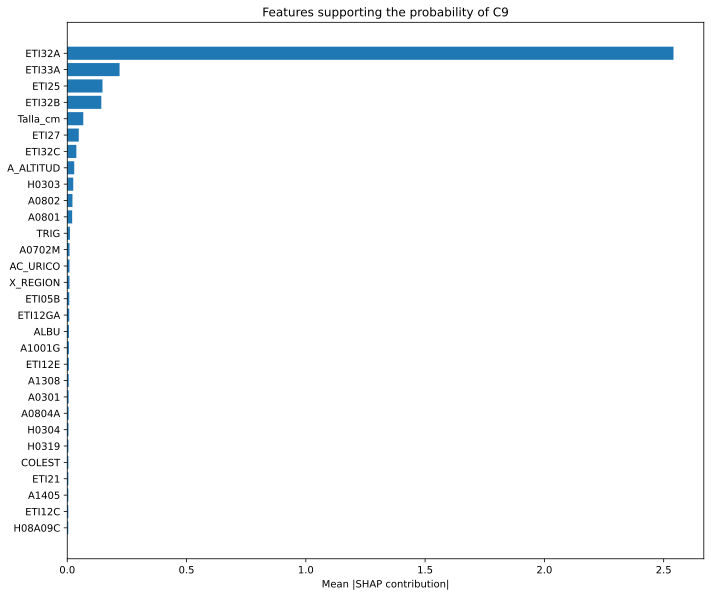


Diagnostic report:  80%|▊| 4/5 [00:10<00:02,  2.74s/stage, generate diagnostic 
Diagnostic report:  80%|▊| 4/5 [00:10<00:02,  2.74s/stage, write manifest and Z
Diagnostic report: 100%|█| 5/5 [00:11<00:00,  2.10s/stage, write manifest and Z
Diagnostic report: 100%|████████████| 5/5 [00:11<00:00,  2.22s/stage, complete]
Raw-variable XGBoost workflow: 100%|█| 5/5 [14:15<00:00, 171.05s/task, complete


,participants,NB_filtered_source_variables,XGBoost_raw_predictors,clusters,uses_bins,uses_binary_rules,glucose_excluded,report,missing_category_audit
0,2530,550,545,10,False,False,True,/Users/cristianjuliocesarpadronmanrique/Deskto...,/Users/cristianjuliocesarpadronmanrique/Deskto...


,OOF_value
accuracy,0.663636
balanced_accuracy,0.631710
macro_precision,0.593668
macro_recall,0.631710
macro_f1,0.604466
weighted_f1,0.639930
cohen_kappa,0.611659
matthews_correlation_coefficient,0.613684
multiclass_log_loss,0.917032
macro_roc_auc_ovr,0.924394


,cluster,n_true,prevalence,n_predicted,TP,FP,FN,TN,precision,sensitivity_recall,specificity,f1,support,roc_auc_ovr,pr_auc_ovr
0,C0,457,0.180632,490,294,196,163,1877,0.600000,0.643326,0.905451,0.620908,457,0.911959,0.627616
1,C1,421,0.166403,476,315,161,106,1948,0.661765,0.748219,0.923661,0.702341,421,0.951473,0.756919
2,C2,361,0.142688,369,322,47,39,2122,0.872629,0.891967,0.978331,0.882192,361,0.991248,0.939532
3,C3,340,0.134387,386,308,78,32,2112,0.797927,0.905882,0.964384,0.848485,340,0.982282,0.868715
4,C4,280,0.110672,328,265,63,15,2187,0.807927,0.946429,0.972000,0.871711,280,0.989514,0.905097
5,C5,265,0.104743,120,31,89,234,2176,0.258333,0.116981,0.960706,0.161039,265,0.719798,0.211372
6,C6,182,0.071937,117,40,77,142,2271,0.341880,0.219780,0.967206,0.267559,182,0.847380,0.284747
7,C7,107,0.042292,81,32,49,75,2374,0.395062,0.299065,0.979777,0.340426,107,0.887862,0.317220
8,C8,99,0.039130,141,54,87,45,2344,0.382979,0.545455,0.964212,0.450000,99,0.963128,0.408348
9,C9,18,0.007115,22,18,4,0,2508,0.818182,1.000000,0.998408,0.900000,18,0.999292,0.873744


In [13]:
if RUN_XGBOOST_CROSS_VALIDATION:
    from ensanut_hba1c.workflows.xgboost_engine import (
        XGBoostConfig,
        run_xgboost_pipeline,
    )
    from ensanut_hba1c.workflows.xgboost_reporting import (
        XGBoostReportConfig,
        export_xgboost_results,
    )

    _preflight_lengths = {
        "X_rows": len(X_RAW_CLUSTER),
        "y_rows": len(RAW_Y),
        "sample_weight_rows": len(RAW_SAMPLE_WEIGHTS),
        "participant_key_rows": len(RAW_PARTICIPANT_KEYS),
    }
    if len(set(_preflight_lengths.values())) != 1:
        raise ValueError(f"Preflight row mismatch: {_preflight_lengths}")
    display(pd.DataFrame([_preflight_lengths]))

    XGB_TASK_PROGRESS.set_stage("nested CV, Optuna, and SHAP")
    XGB_RESULT = run_xgboost_pipeline(
        X=X_RAW_CLUSTER,
        y=RAW_Y,
        sample_weights=RAW_SAMPLE_WEIGHTS,
        output_dir=RAW_OUTPUT_DIR,
        config=XGBoostConfig(
            random_state=XGB_RANDOM_STATE,
            outer_cv_splits=XGB_CV_N_SPLITS,
            inner_cv_splits=OPTUNA_INNER_CV_SPLITS,
            run_optuna=RUN_OPTUNA_HYPERPARAMETER_SEARCH,
            trials_per_outer_fold=OPTUNA_TRIALS_PER_OUTER_FOLD,
            final_trials=OPTUNA_FINAL_N_TRIALS,
            optuna_timeout_seconds=OPTUNA_TIMEOUT_SECONDS,
            optuna_study_basename=OPTUNA_STUDY_BASENAME,
            reuse_existing_studies=OPTUNA_REUSE_EXISTING_STUDIES,
            optuna_startup_trials=OPTUNA_N_STARTUP_TRIALS,
            optuna_pruner_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            optuna_pruner_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
            objective_metric=OPTUNA_OBJECTIVE_METRIC,
            optuna_n_jobs=OPTUNA_N_JOBS,
            max_estimators=XGB_MAX_ESTIMATORS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            tree_method=XGB_TREE_METHOD,
            n_jobs=XGB_N_JOBS,
            use_balanced_class_weights=XGB_USE_BALANCED_CLASS_WEIGHTS,
            shap_max_rows_per_fold=XGB_SHAP_MAX_ROWS_PER_FOLD,
            learning_rate_min=OPTUNA_LEARNING_RATE_MIN,
            learning_rate_max=OPTUNA_LEARNING_RATE_MAX,
            max_depth_min=OPTUNA_MAX_DEPTH_MIN,
            max_depth_max=OPTUNA_MAX_DEPTH_MAX,
            min_child_weight_min=OPTUNA_MIN_CHILD_WEIGHT_MIN,
            min_child_weight_max=OPTUNA_MIN_CHILD_WEIGHT_MAX,
            subsample_min=OPTUNA_SUBSAMPLE_MIN,
            subsample_max=OPTUNA_SUBSAMPLE_MAX,
            colsample_bytree_min=OPTUNA_COLSAMPLE_BYTREE_MIN,
            colsample_bytree_max=OPTUNA_COLSAMPLE_BYTREE_MAX,
            gamma_min=OPTUNA_GAMMA_MIN,
            gamma_max=OPTUNA_GAMMA_MAX,
            reg_alpha_min=OPTUNA_REG_ALPHA_MIN,
            reg_alpha_max=OPTUNA_REG_ALPHA_MAX,
            reg_lambda_min=OPTUNA_REG_LAMBDA_MIN,
            reg_lambda_max=OPTUNA_REG_LAMBDA_MAX,
            max_bin_options=tuple(OPTUNA_MAX_BIN_OPTIONS),
            max_cat_to_onehot_options=tuple(OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS),
            max_cat_threshold_options=tuple(OPTUNA_MAX_CAT_THRESHOLD_OPTIONS),
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    XGB_TASK_PROGRESS.complete("nested CV complete")

    XGB_TASK_PROGRESS.set_stage("export diagnostic report")
    XGB_OUTPUTS = export_xgboost_results(
        XGB_RESULT,
        RAW_OUTPUT_DIR,
        participant_keys=RAW_PARTICIPANT_KEYS,
        feature_selection_audit=(
            PREPARED_RAW_CLUSTER_DATASET.feature_selection.audit
        ),
        model_audit=PREPARED_RAW_CLUSTER_DATASET.model_audit,
        config=XGBoostReportConfig(
            dpi=XGB_REPORT_DPI,
            top_global_features=XGB_TOP_FEATURES_GLOBAL,
            top_features_per_cluster=XGB_TOP_FEATURES_PER_CLUSTER,
            top_confusion_pairs=XGB_TOP_CONFUSION_PAIRS,
            top_optuna_parameters=XGB_TOP_OPTUNA_PARAMETERS,
            calibration_bins=XGB_CALIBRATION_BINS,
            save_individual_plots=XGB_SAVE_INDIVIDUAL_PLOTS,
            show_in_notebook=XGB_SHOW_ALL_DIAGNOSTIC_FIGURES,
            show_summary_page_in_notebook=False,
            verbose=False,
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    PREPARED_RAW_CLUSTER_DATASET.feature_selection.export(
        RAW_OUTPUT_DIR / "feature_selection"
    )
    XGB_TASK_PROGRESS.complete("reports exported")
    XGB_TASK_PROGRESS.close("complete")

    display(pd.DataFrame([{
        "participants": len(X_RAW_CLUSTER),
        "NB_filtered_source_variables": len(RAW_SOURCE_VARIABLES),
        "XGBoost_raw_predictors": X_RAW_CLUSTER.shape[1],
        "clusters": RAW_Y.nunique(),
        "uses_bins": False,
        "uses_binary_rules": False,
        "glucose_excluded": "GLU_SUERO" not in X_RAW_CLUSTER.columns,
        "report": str(XGB_OUTPUTS["pdf"]),
        "missing_category_audit": str(
            RAW_OUTPUT_DIR
            / "textual_missing_categories_replaced_with_nan.csv"
        ),
    }]))
    display(XGB_RESULT.global_metrics.T.rename(columns={0: "OOF_value"}))
    display(XGB_RESULT.metrics_by_cluster)
else:
    print("Raw-variable XGBoost cross-validation is disabled.")


In [14]:
if RUN_XGBOOST_CROSS_VALIDATION:
    # Final representation, leakage, missingness, and dtype audit.
    RAW_FEATURE_AUDIT = pd.DataFrame({
        "source_variable": X_RAW_CLUSTER.columns.astype(str),
        "dtype": [str(dtype) for dtype in X_RAW_CLUSTER.dtypes],
        "nonmissing_n": [
            int(X_RAW_CLUSTER[column].notna().sum())
            for column in X_RAW_CLUSTER.columns
        ],
        "missing_n": [
            int(X_RAW_CLUSTER[column].isna().sum())
            for column in X_RAW_CLUSTER.columns
        ],
        "missing_fraction": [
            float(X_RAW_CLUSTER[column].isna().mean())
            for column in X_RAW_CLUSTER.columns
        ],
        "unique_nonmissing": [
            int(X_RAW_CLUSTER[column].nunique(dropna=True))
            for column in X_RAW_CLUSTER.columns
        ],
    })

    forbidden_present = sorted(
        set(RAW_FEATURE_AUDIT["source_variable"])
        .intersection(XGB_NON_GLYCEMIC_EXCLUSIONS)
    )
    assert not forbidden_present, (
        "Forbidden variables were detected in the final raw matrix: "
        f"{forbidden_present}"
    )

    bin_like_columns = RAW_FEATURE_AUDIT.loc[
        RAW_FEATURE_AUDIT["source_variable"].str.match(r"^R\d+__", na=False),
        "source_variable",
    ].tolist()
    assert not bin_like_columns, (
        "Binary/bin-rule columns were detected in the raw matrix: "
        f"{bin_like_columns[:20]}"
    )

    RAW_FEATURE_AUDIT.to_csv(
        RAW_OUTPUT_DIR / "raw_feature_audit.csv",
        index=False,
    )

    display(
        RAW_FEATURE_AUDIT
        .sort_values(
            ["missing_fraction", "source_variable"],
            ascending=[False, True],
        )
        .head(60)
    )
    print("Final raw matrix shape:", X_RAW_CLUSTER.shape)
    print("Number of original source-variable predictors:", X_RAW_CLUSTER.shape[1])
    print("Quantile bins used by final XGBoost:", False)
    print("Binary evidence rules used by final XGBoost:", False)
    print("GLU_SUERO present:", "GLU_SUERO" in X_RAW_CLUSTER.columns)
    print("HB1AC present:", "HB1AC" in X_RAW_CLUSTER.columns)
    print(
        "Textual missing/non-response labels replaced with NaN:",
        int(RAW_MISSING_CATEGORY_AUDIT["n_replaced_with_nan"].sum())
        if not RAW_MISSING_CATEGORY_AUDIT.empty
        else 0,
    )


,source_variable,dtype,nonmissing_n,missing_n,missing_fraction,unique_nonmissing
272,A03061AA,float32,52,2478,0.979447,5
273,A0312B,float32,58,2472,0.977075,3
271,A0313A,float32,66,2464,0.973913,4
263,A0304BB,float32,79,2451,0.968775,5
181,H0314,float32,83,2447,0.967194,2
456,A1004J,float32,89,2441,0.964822,2
268,A0309M,float32,94,2436,0.962846,9
269,A0310,float32,94,2436,0.962846,2
328,A09221A,float32,100,2430,0.960474,2
329,A09222A,float32,100,2430,0.960474,2


Final raw matrix shape: (2530, 545)
Number of original source-variable predictors: 545
Quantile bins used by final XGBoost: False
Binary evidence rules used by final XGBoost: False
GLU_SUERO present: False
HB1AC present: False
Textual missing/non-response labels replaced with NaN: 0


### Interpretation of this audit

- The XGBoost classifier receives the retained **source variables**, not the interval bins or binary rules used by hierarchical signed evidence.
- Numerical predictors retain their prepared continuous/discrete values; the notebook does not apply `qcut`, `cut`, or evidence-bin indicators to the final XGBoost matrix.
- Textual missing/non-response categories are converted to `NaN` and are not treated as predictive categories. Native missingness is retained for the model's missing-value handling.
- High performance indicates that the fixed SHAP-derived labels are recoverable from non-glycemic original-variable information.
- It does **not** show that the communities were discovered independently of glucose, because glucose participated in the original HbA1c model and SHAP representation.
- It does **not** constitute external, biological, or clinical subtype validation.


In [15]:
# Optional compact manuscript-ready summary after execution.
if RUN_XGBOOST_CROSS_VALIDATION:
    _metric_series = XGB_RESULT.global_metrics
    if isinstance(_metric_series, pd.DataFrame):
        _metric_series = _metric_series.iloc[:, 0]

    print(
        "A nested-cross-validated XGBoost audit using "
        f"{X_RAW_CLUSTER.shape[1]:,} non-glycemic source-variable predictors "
        "without interval binning yielded "
        f"accuracy={float(_metric_series.get('accuracy', np.nan)):.3f}, "
        f"macro-F1={float(_metric_series.get('macro_f1', np.nan)):.3f}, and "
        f"macro one-versus-rest ROC-AUC="
        f"{float(_metric_series.get('macro_roc_auc_ovr', np.nan)):.3f}. "
        "Textual missing/non-response categories were converted to missing "
        "values before model-matrix preparation. These results quantify "
        "internal label recoverability from the fixed non-glycemic raw-variable "
        "representation."
    )


A nested-cross-validated XGBoost audit using 545 non-glycemic source-variable predictors without interval binning yielded accuracy=nan, macro-F1=nan, and macro one-versus-rest ROC-AUC=nan. Textual missing/non-response categories were converted to missing values before model-matrix preparation. These results quantify internal label recoverability from the fixed non-glycemic raw-variable representation.


## Pre-rendered figure gallery

**26 figures** embedded below as PNG/JPEG outputs. No execution is required.

### Figure 1
*From original cell 21: 8.2 Final heatmap*

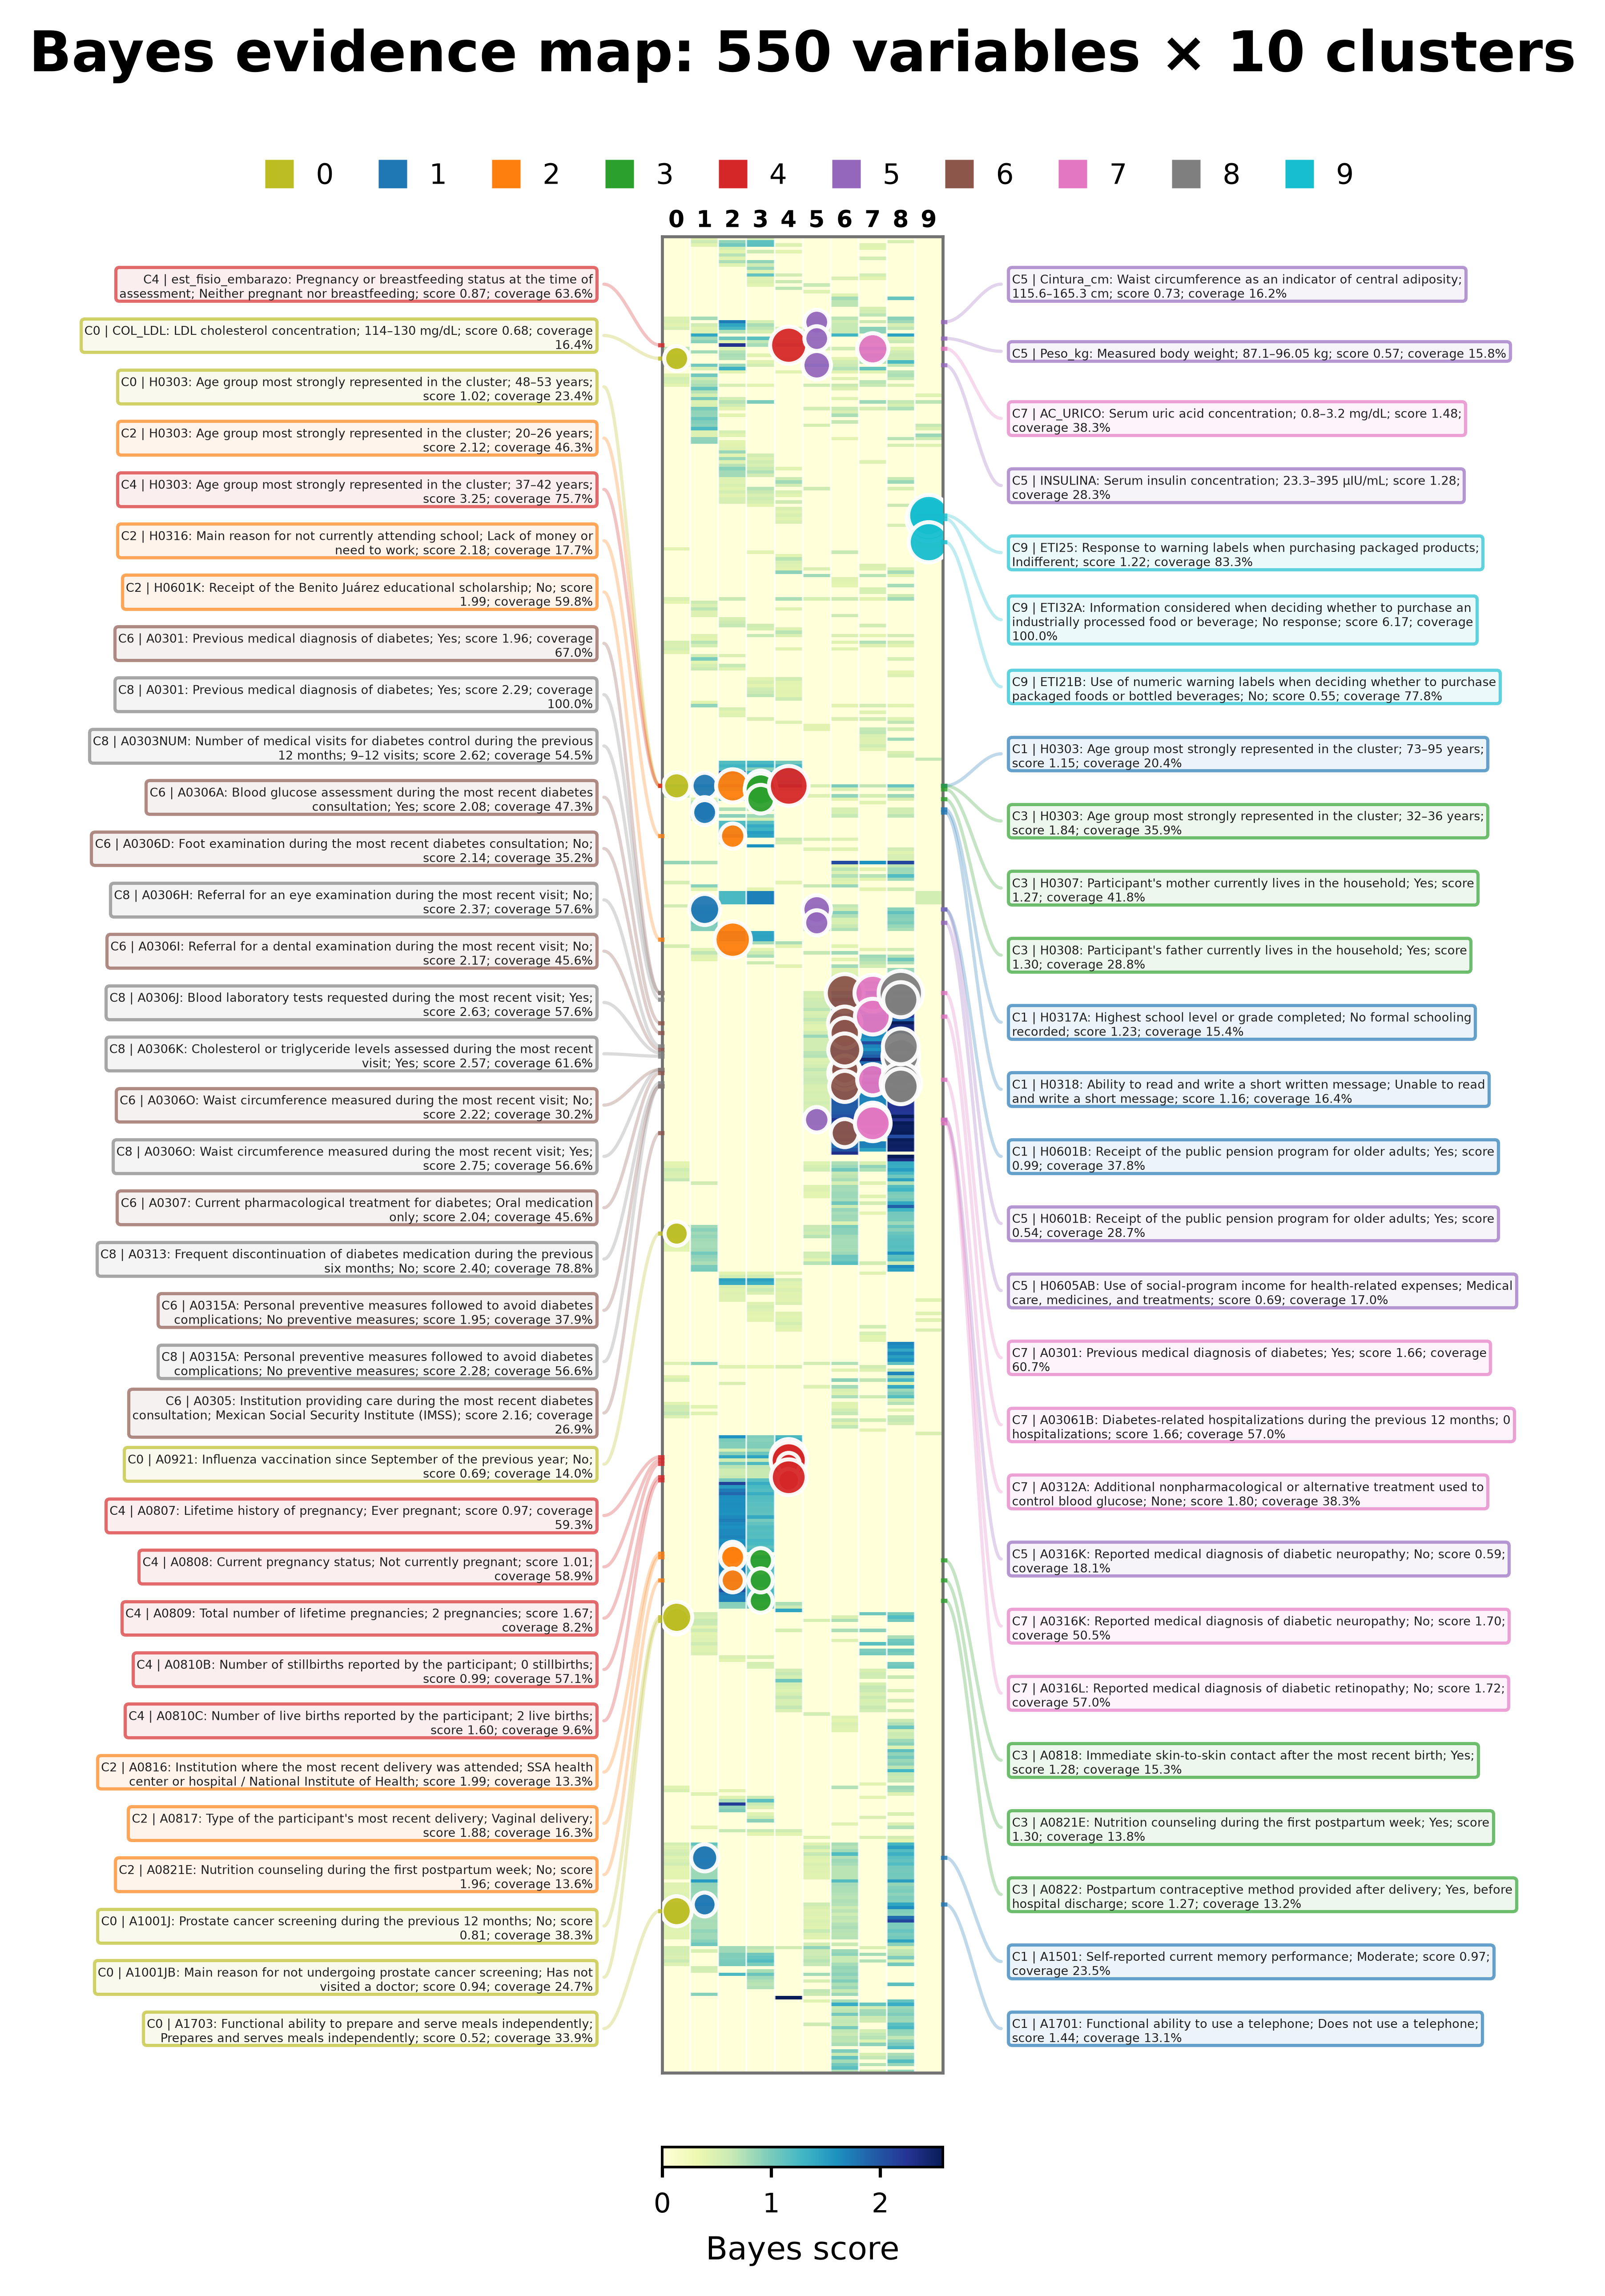

### Figure 2
*From original cell 22: 8.2 Final heatmap*

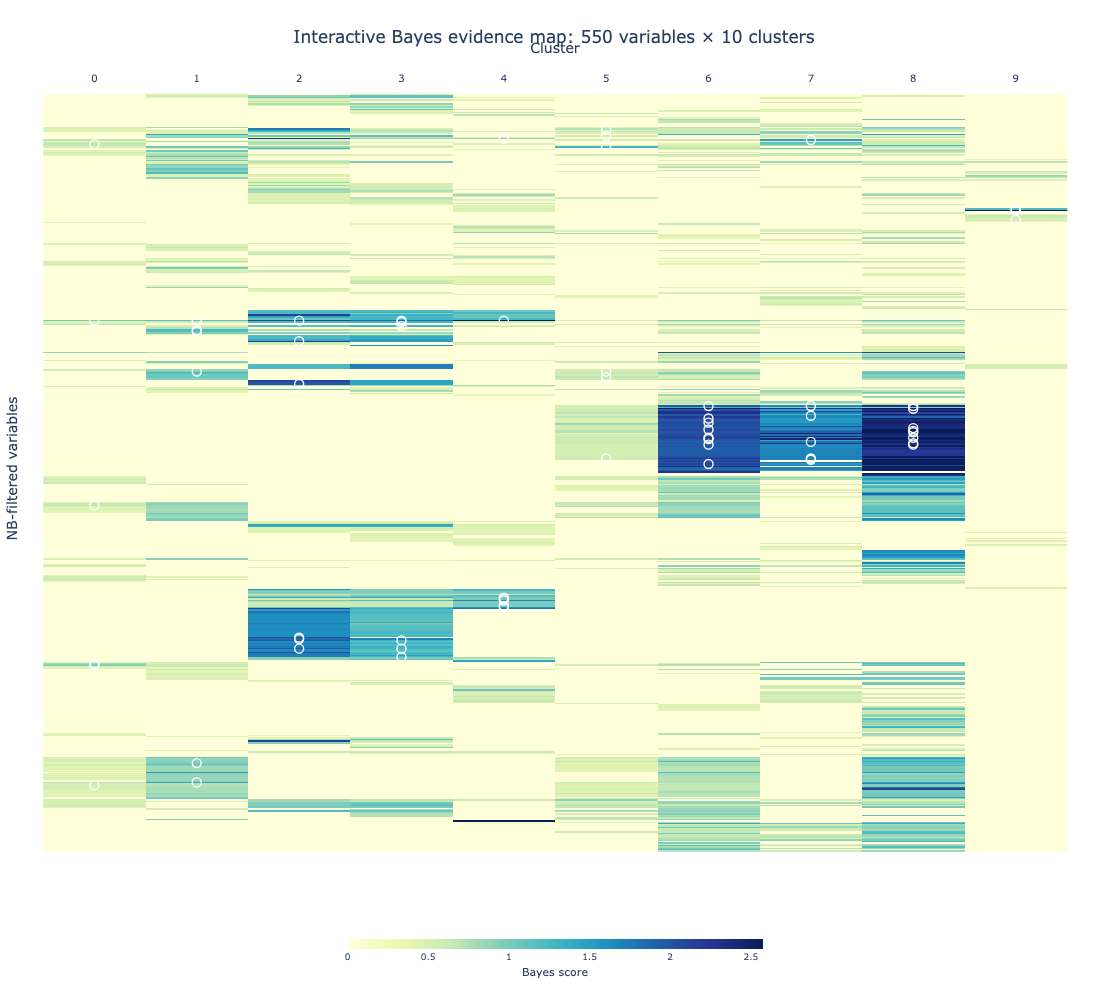

### Figure 3
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

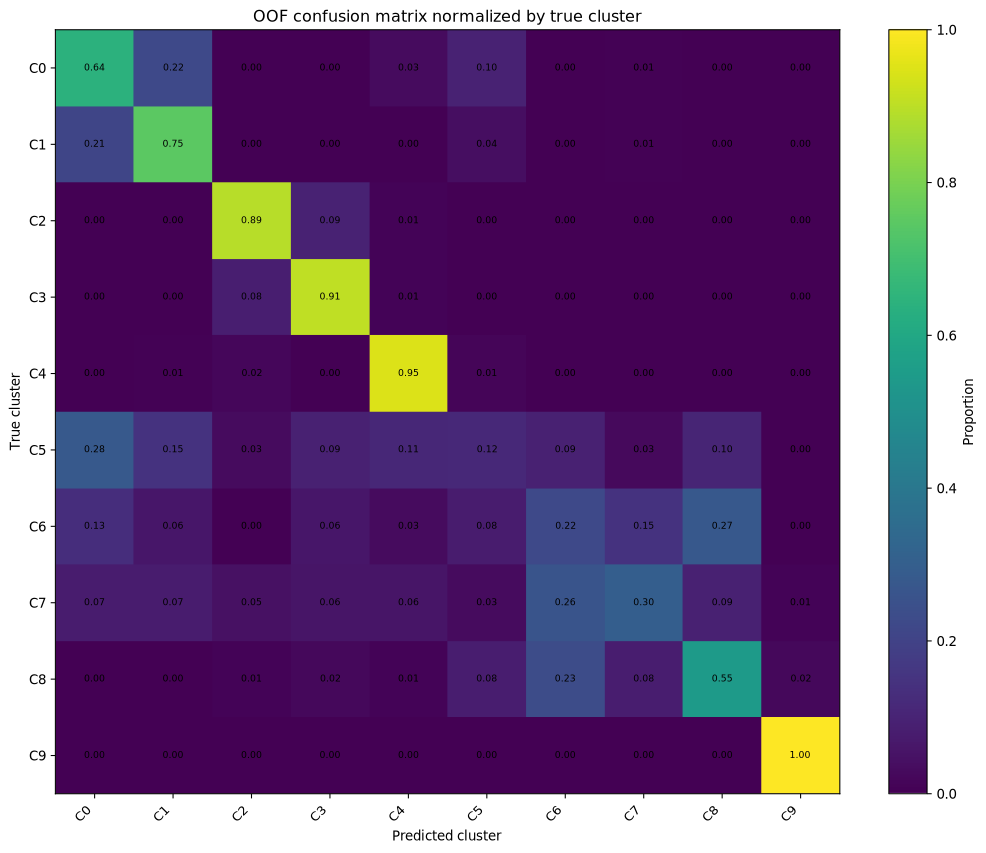

### Figure 4
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

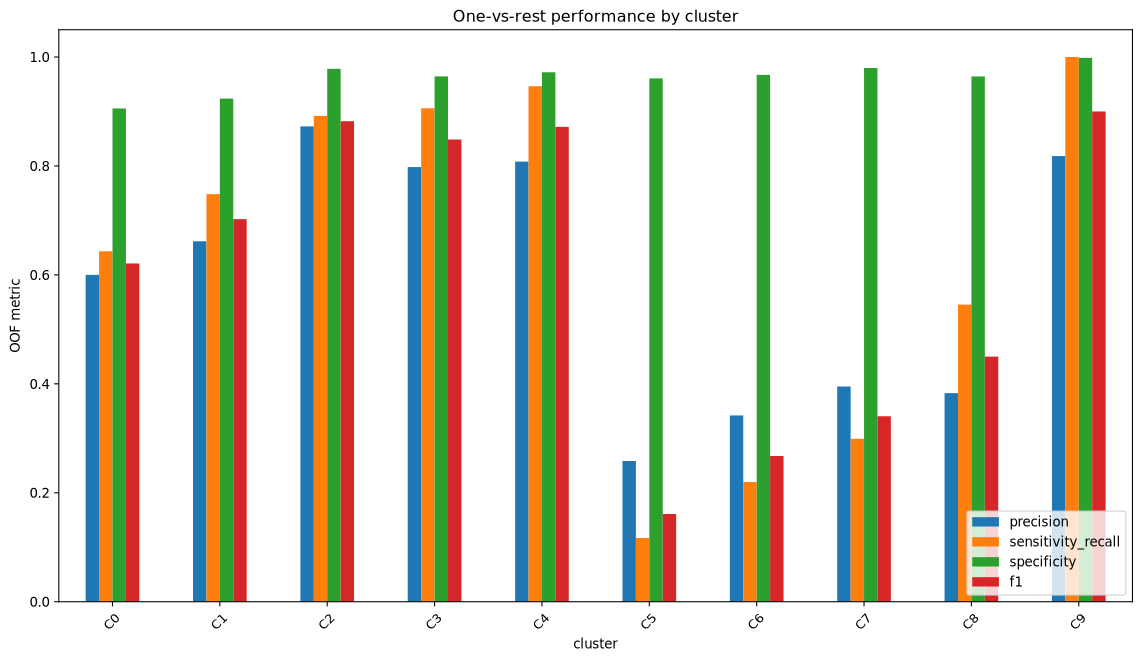

### Figure 5
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

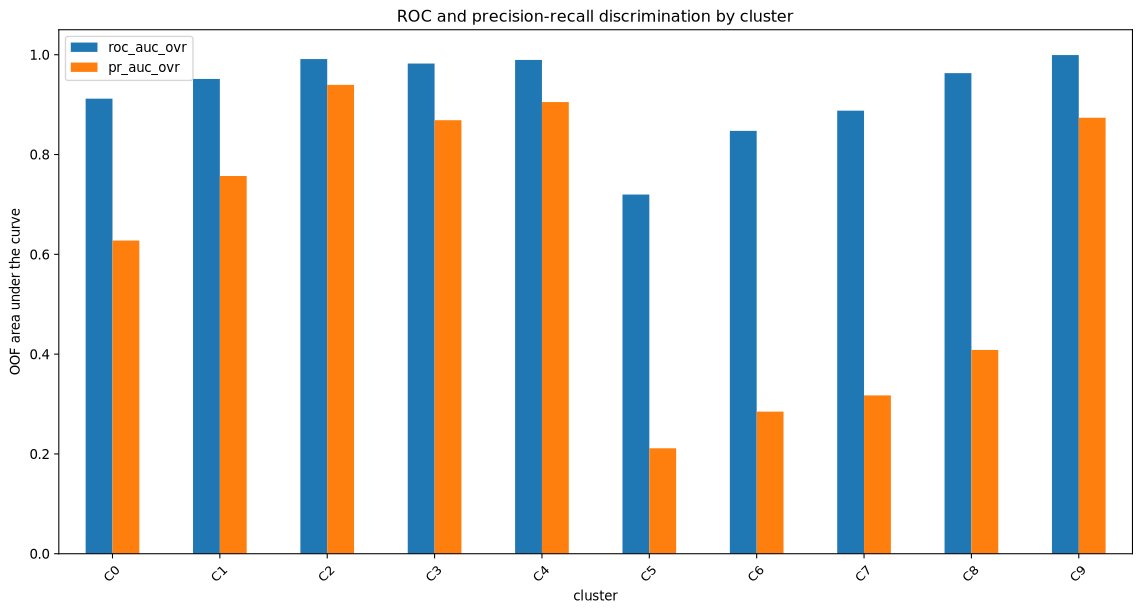

### Figure 6
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

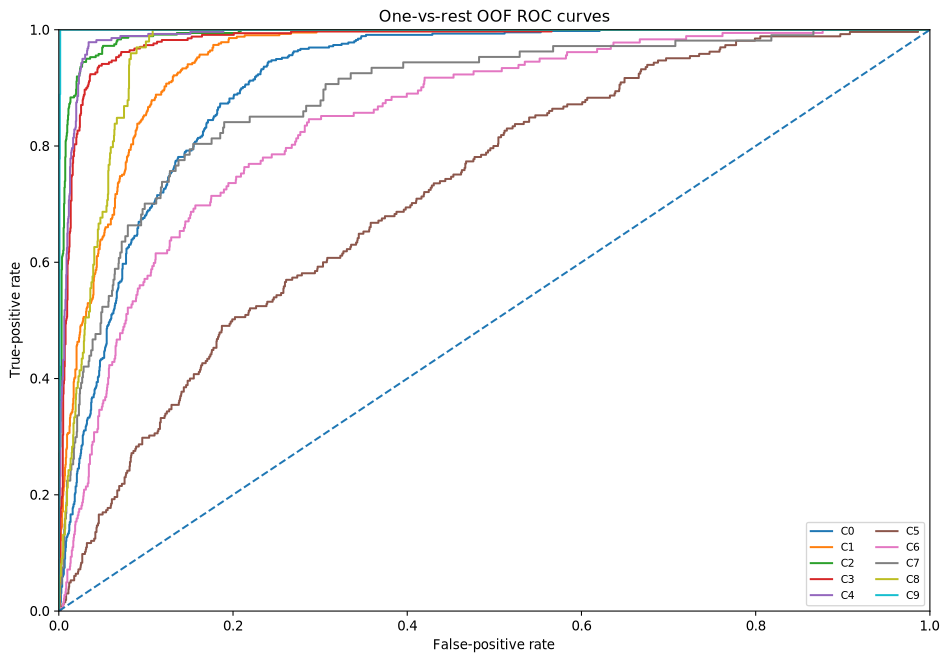

### Figure 7
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

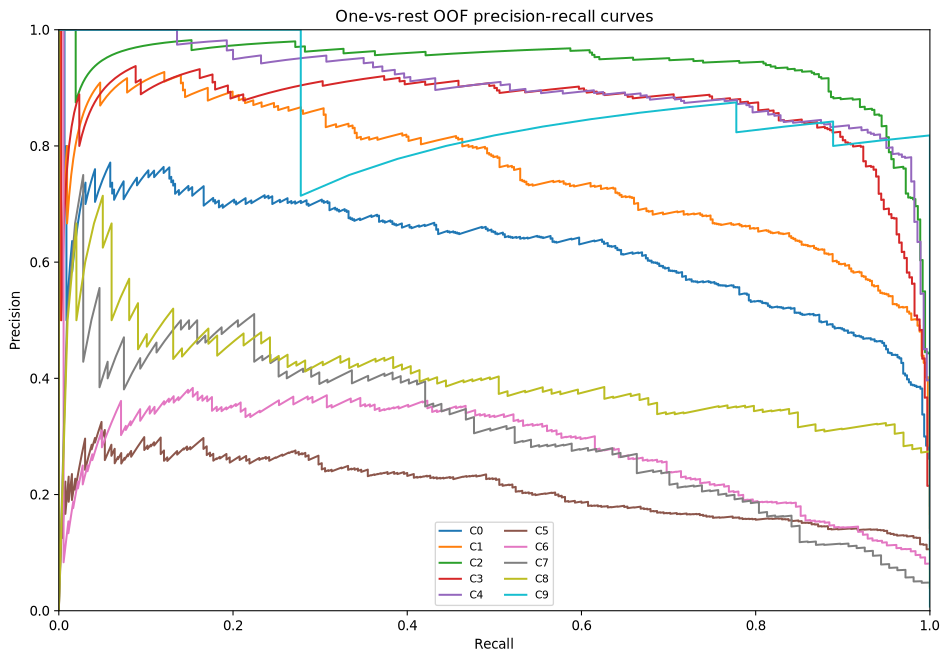

### Figure 8
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

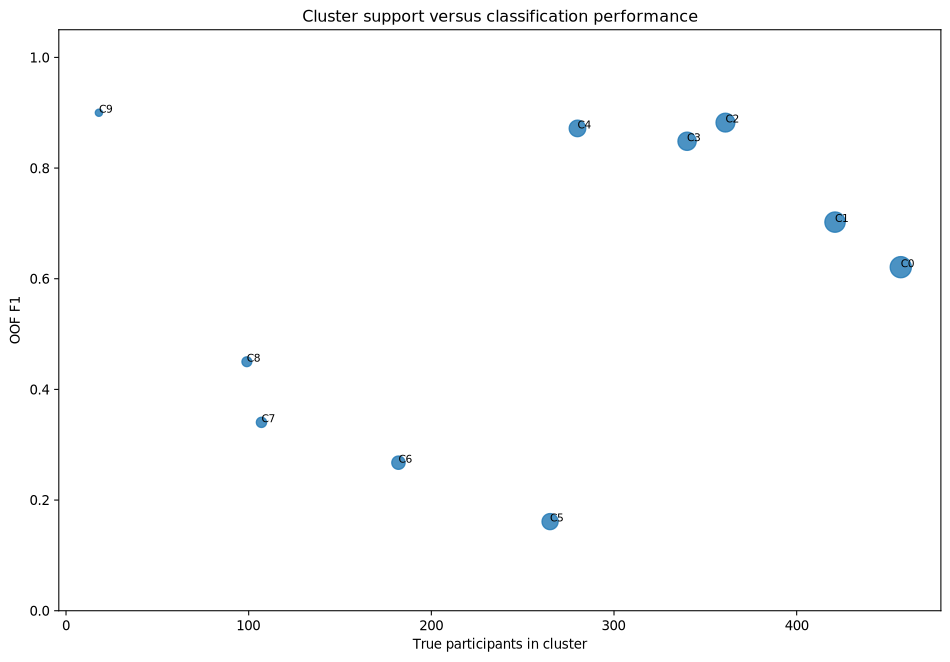

### Figure 9
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

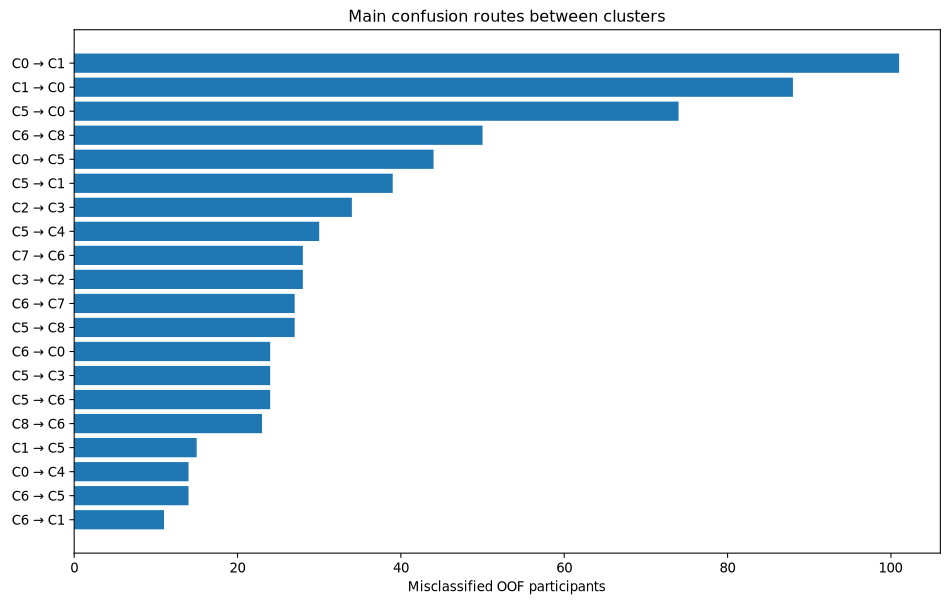

### Figure 10
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

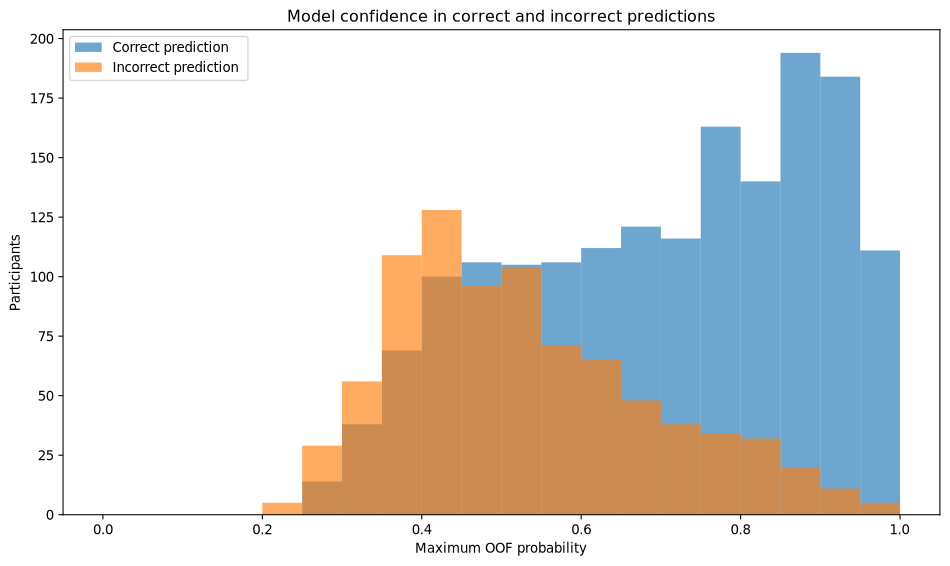

### Figure 11
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

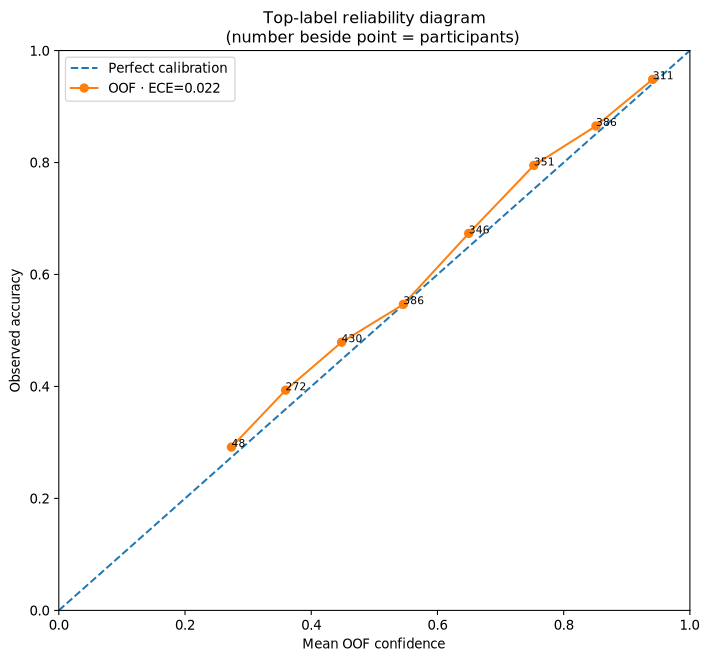

### Figure 12
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

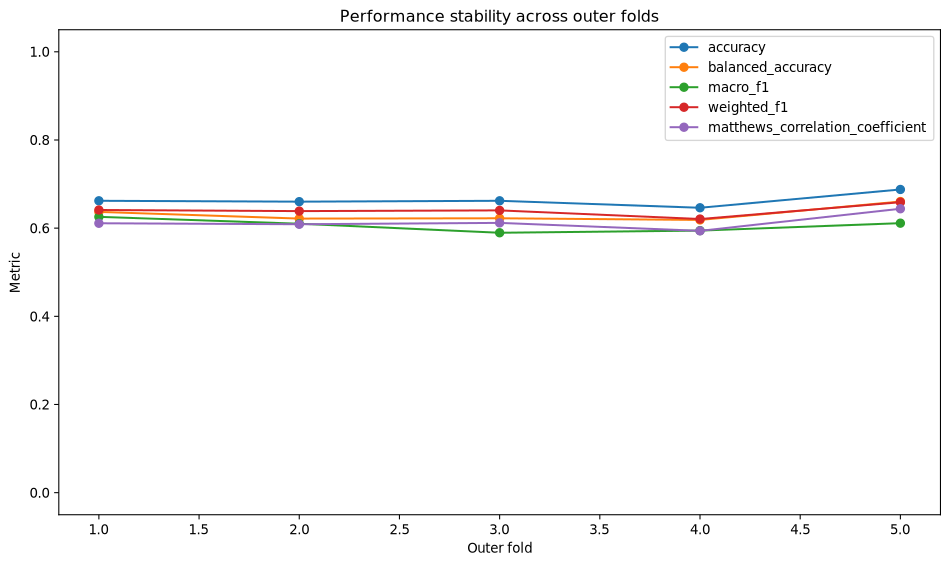

### Figure 13
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

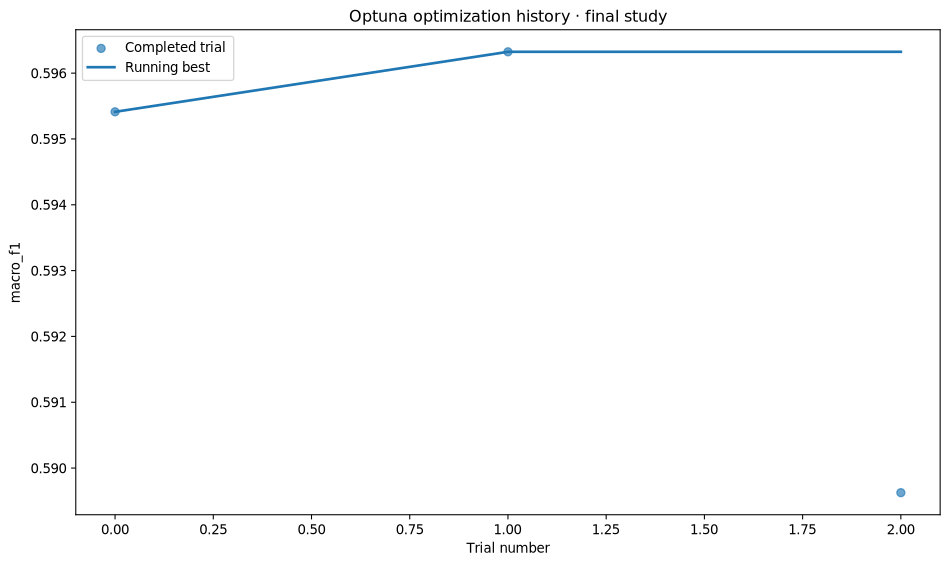

### Figure 14
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

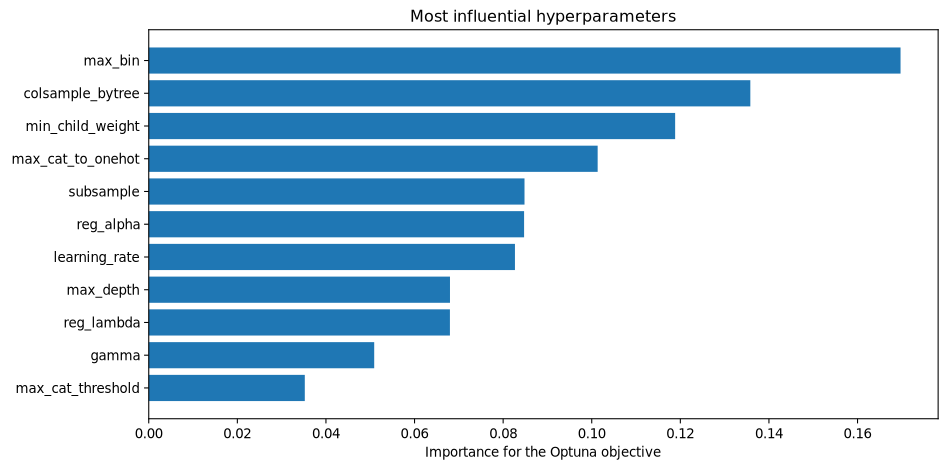

### Figure 15
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

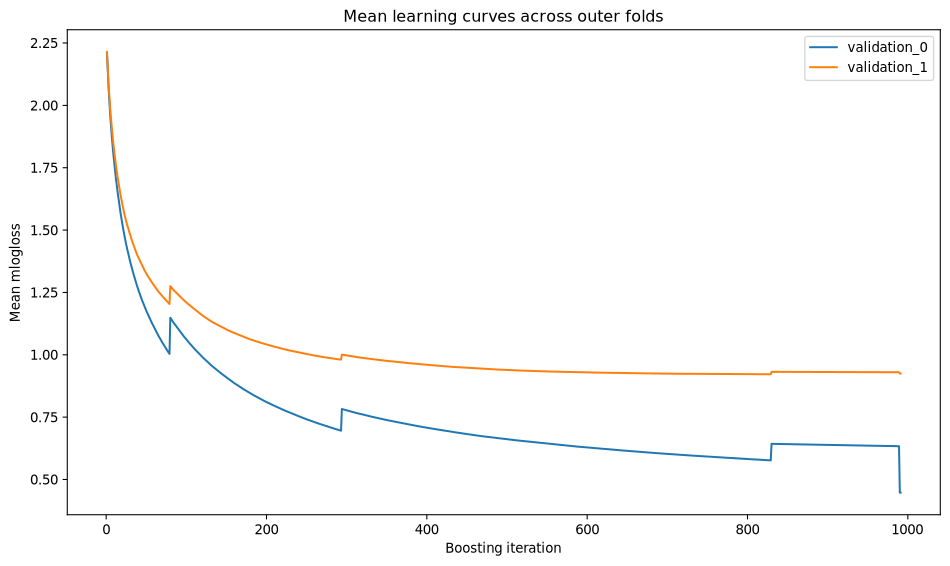

### Figure 16
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

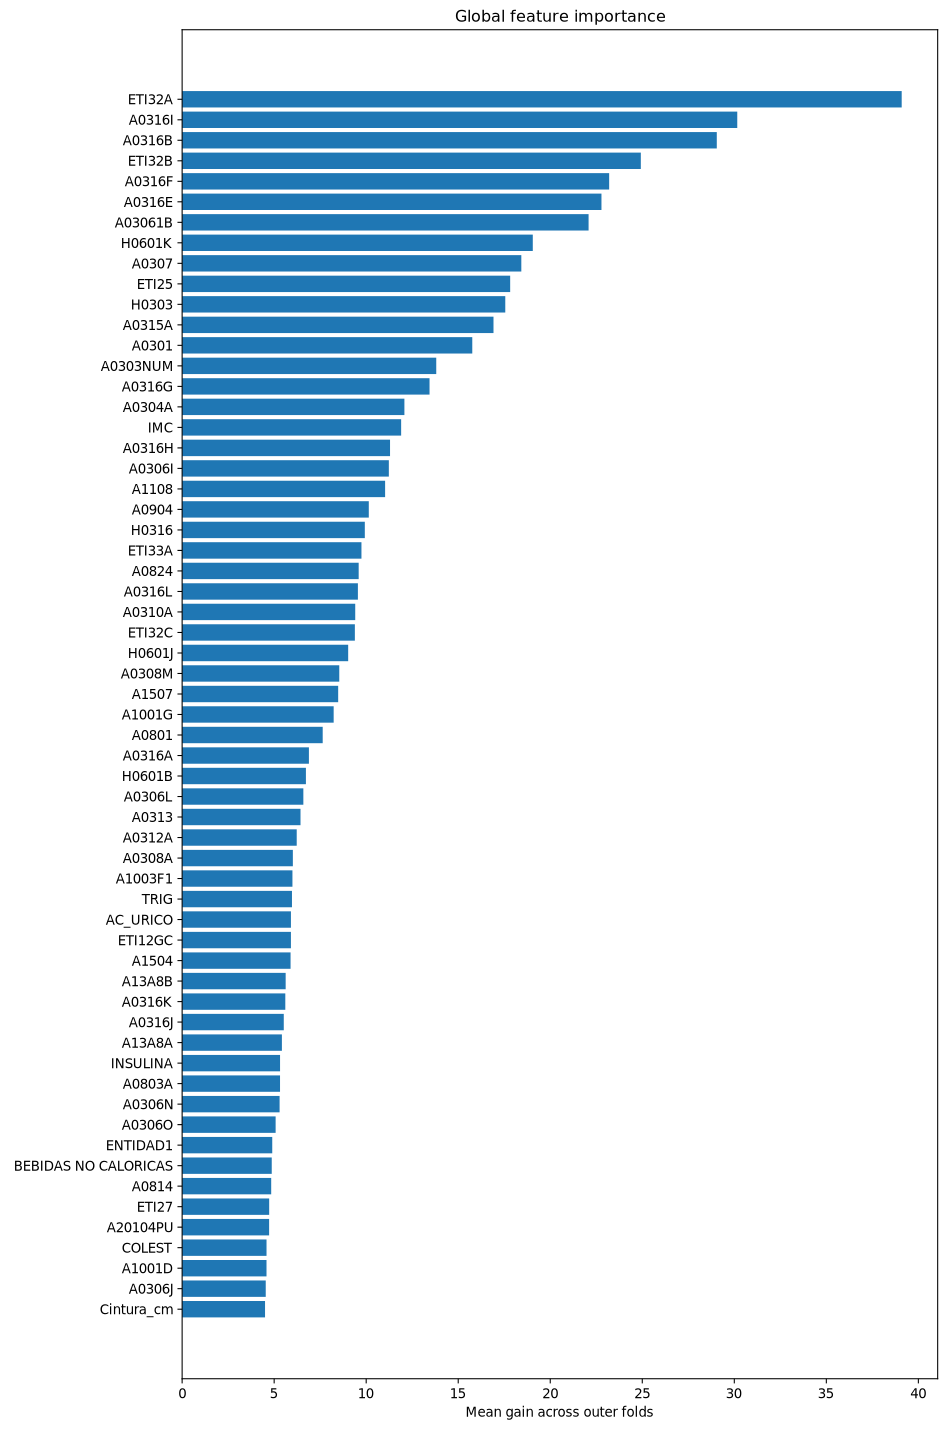

### Figure 17
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

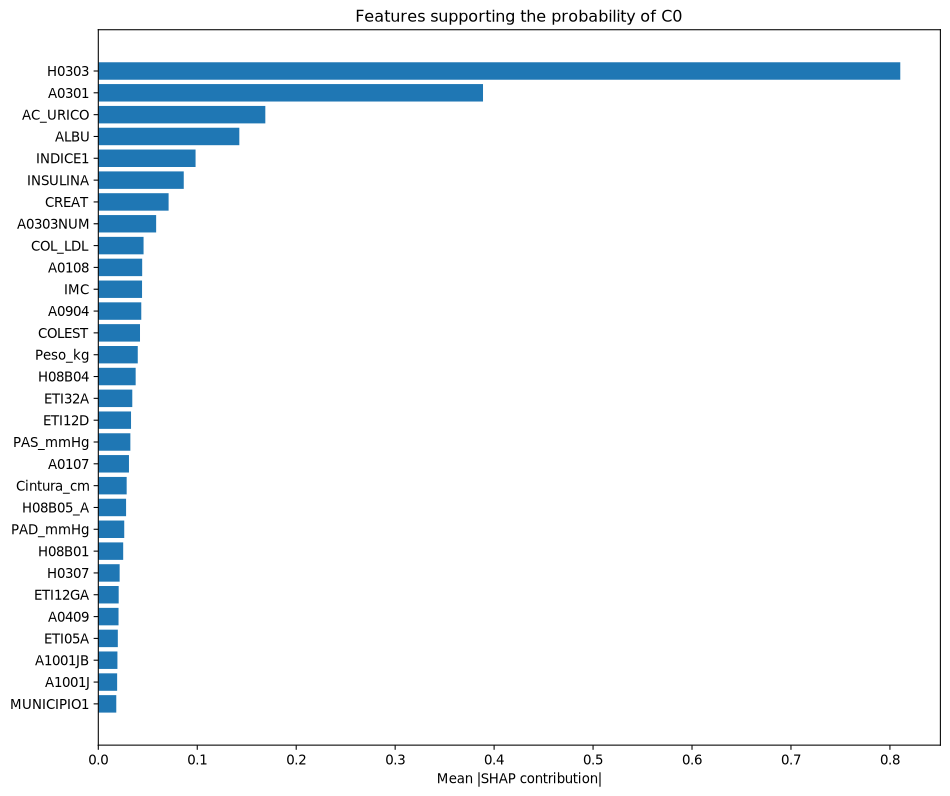

### Figure 18
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

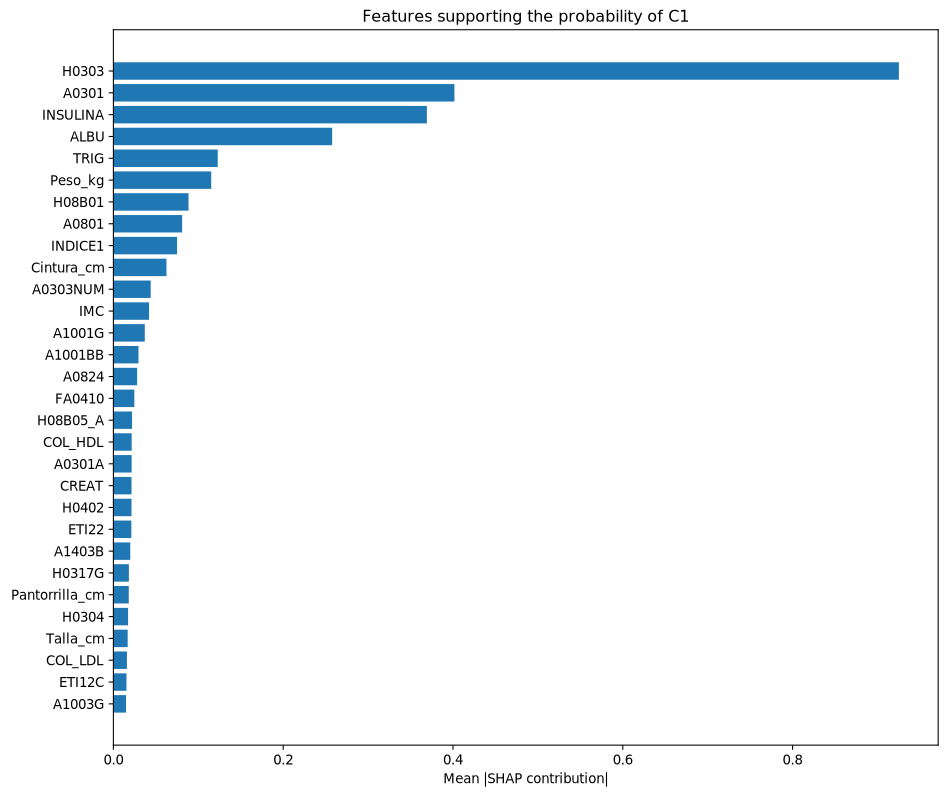

### Figure 19
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

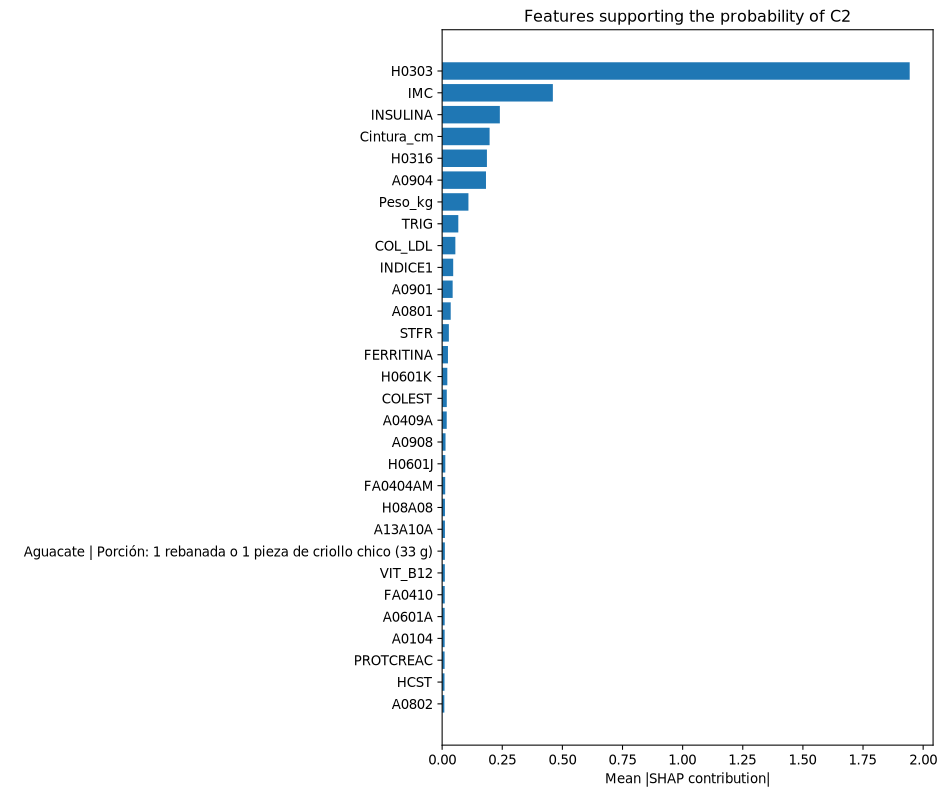

### Figure 20
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

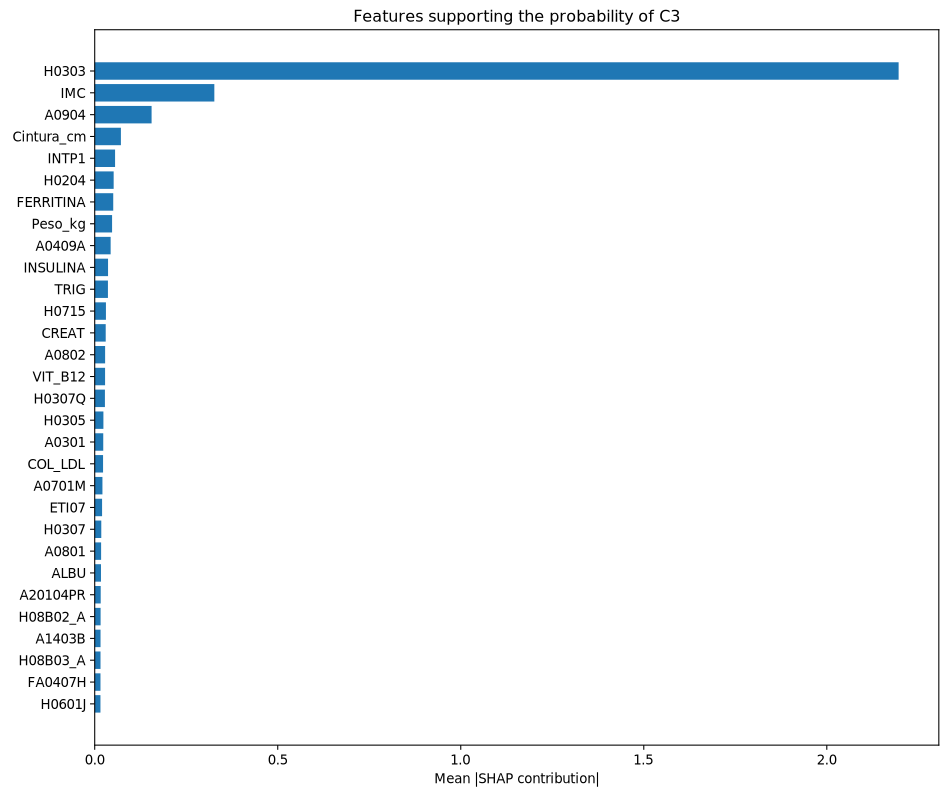

### Figure 21
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

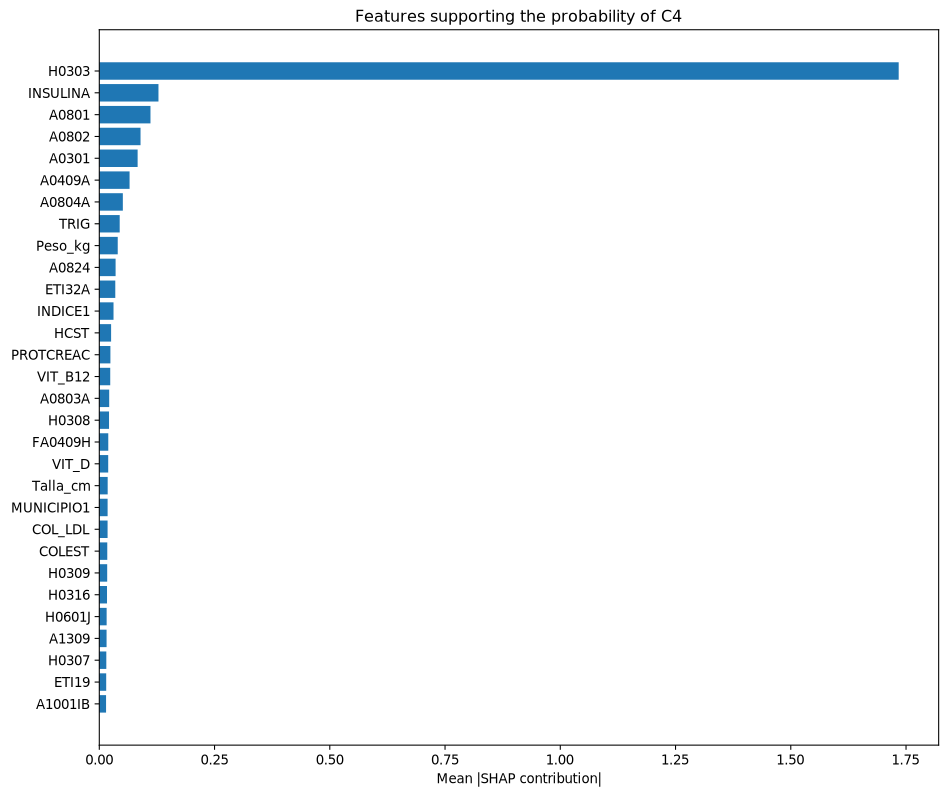

### Figure 22
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

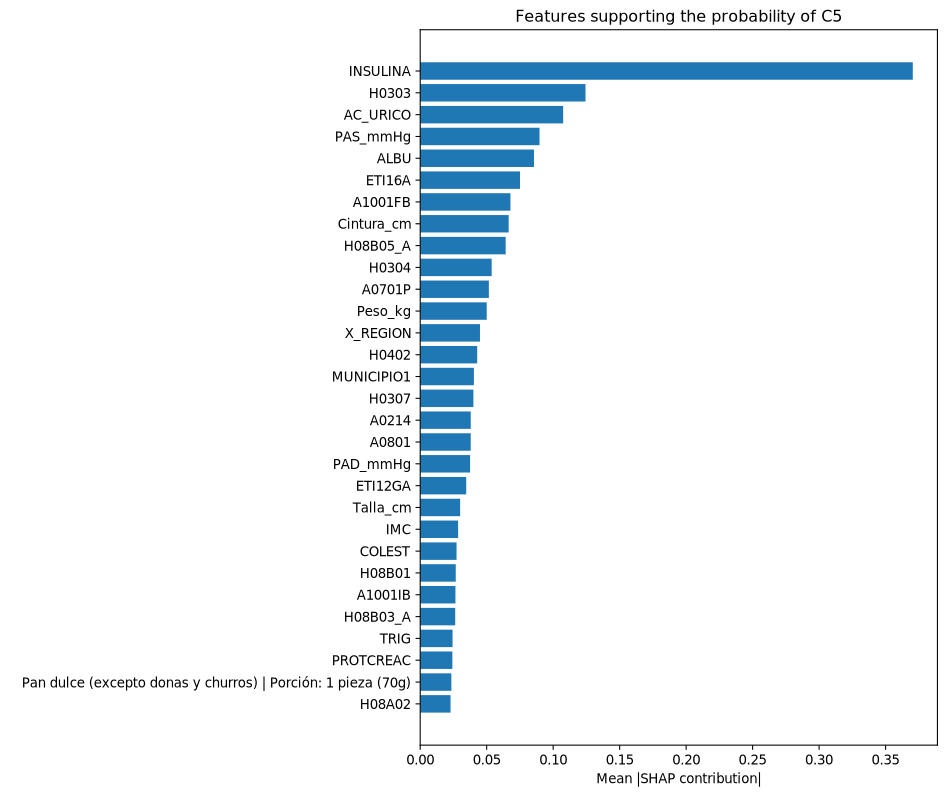

### Figure 23
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

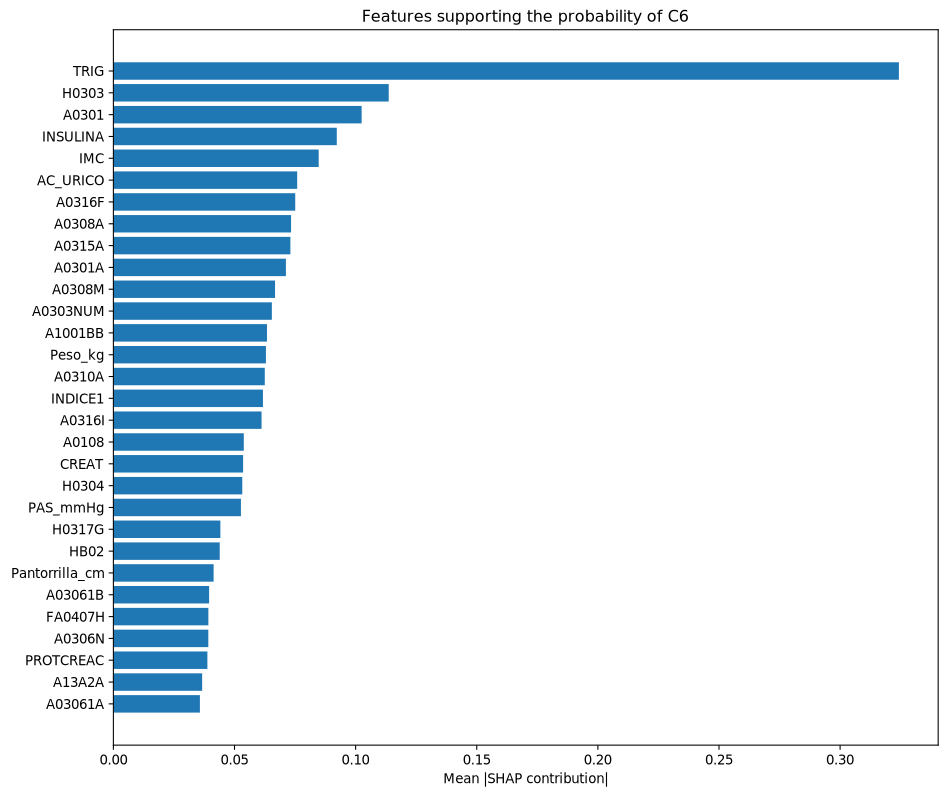

### Figure 24
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

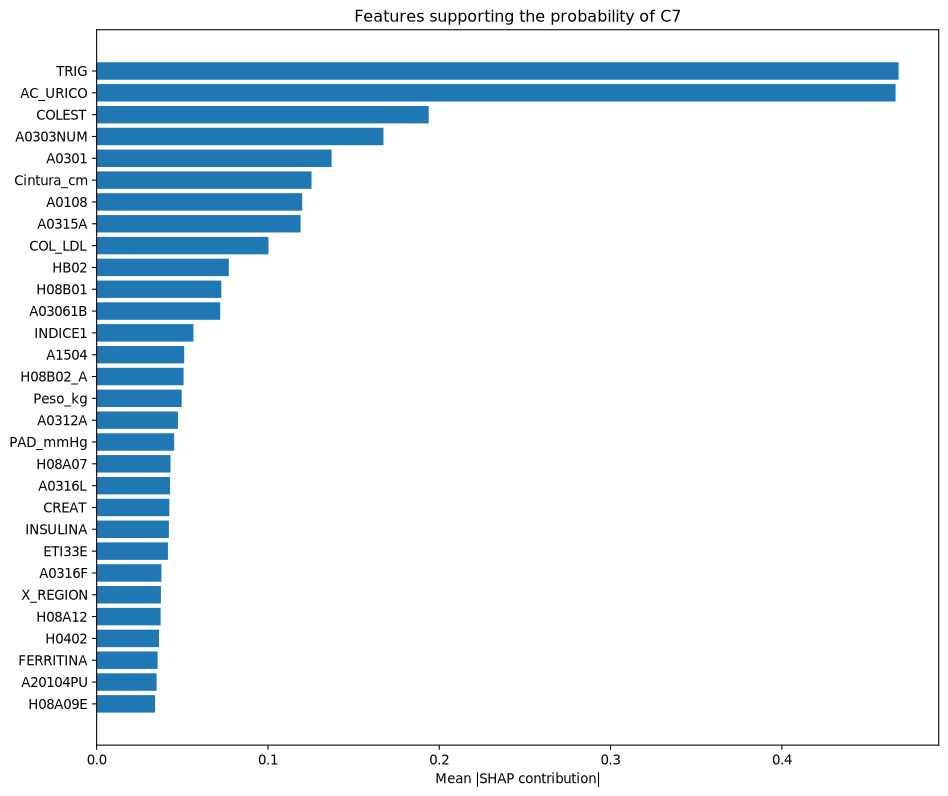

### Figure 25
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

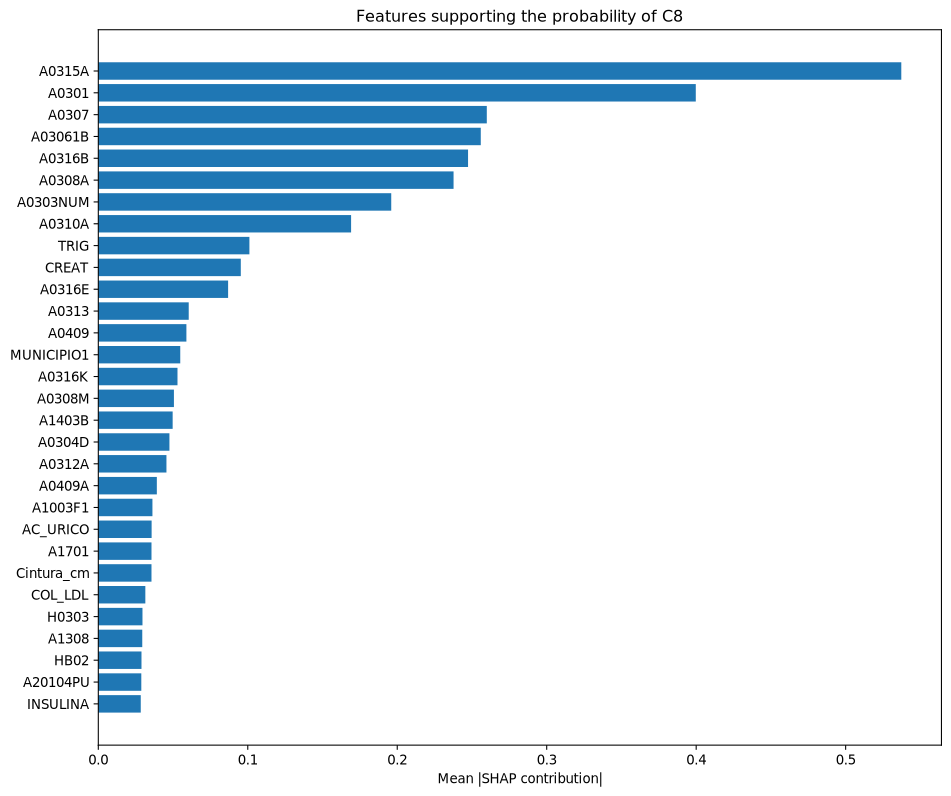

### Figure 26
*From original cell 26: 9. Non-glycemic raw-variable XGBoost and complete OOF diagnostics*

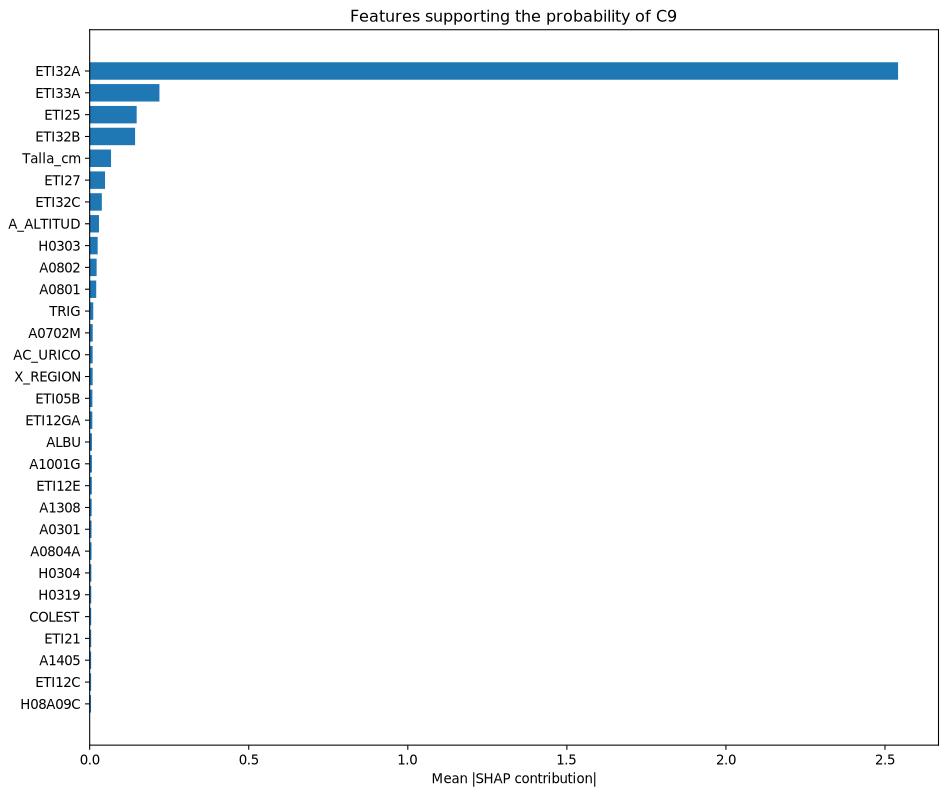

In [ ]:
# PRE-RENDERED FIGURE GALLERY
# Outputs are already embedded; do not run this cell.
